In [11]:
!pip install gputil

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for gputil: filename=GPUtil-1.4.0-py3-none-any.whl size=7401 sha256=05c4fe81e26c1aff8023149a8eadaf9745544104853c99f411707c39471f1ce7
  Stored in directory: C:\Users\osherr\AppData\Local\Temp\pip-ephem-wheel-cache-jxgpotwq\wheels\ba\03\bb\7a97840eb54479b328672e15a536e49dc60da200fb21564d53
Successfully built gputil


In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  2


In [2]:
import tensorflow as tf
import numpy as np
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [3]:
import gc
import tensorflow as tf
from tensorflow.keras.backend import clear_session

# Define a function to clear memory after each model training
def clear_memory():
    clear_session()  # Clear the Keras backend session
    gc.collect()  # Run garbage collection
    print("Memory clearing process completed successfully.")

# Example usage after training a model
# Assume model training code here

# Clear memory after training the model
clear_memory()


Memory clearing process completed successfully.


In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import rasterio
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from keras.optimizers import Adam

def iou_metric(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    
    iou = intersection / (union + K.epsilon())
    return iou

def weighted_binary_crossentropy(y_true, y_pred, ws=1.0, wn=0.05):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    epsilon = tf.keras.backend.epsilon()
    
    y_true_flat = K.flatten(y_true)
    y_pred_flat = K.flatten(y_pred)
    
    loss = -ws * y_true_flat * tf.math.log(y_pred_flat + epsilon) - wn * (1 - y_true_flat) * tf.math.log(1 - y_pred_flat + epsilon)
    return tf.reduce_mean(loss)


def bce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return K.binary_crossentropy(y_true, y_pred)

def dice_bce_loss(y_true, y_pred, alpha=0.5):
    d_loss = dice_loss(y_true, y_pred)
    b_loss = bce_loss(y_true, y_pred)
    return alpha * b_loss + (1 - alpha) * d_loss

    
def dice_coefficient(y_true, y_pred):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)    

def dice_loss(y_true, y_pred):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)

# Define weighted Dice loss
def weighted_dice_loss(y_true, y_pred, ws=1.0, wn=0.07): #0.05 ##0.07 final
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_flat = K.flatten(y_true)
    y_pred_flat = K.flatten(y_pred)
    
    intersection = K.sum(ws * y_true_flat * y_pred_flat)
    denominator = K.sum(ws * y_true_flat + wn * (1 - y_true_flat) * y_pred_flat)
    
    dice_loss = 1 - (2. * intersection + 1) / (denominator + 1)
    return dice_loss
 
def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)

def tversky_loss(y_true, y_pred, alpha=1.0, beta=0.3):
    y_true_pos = tf.cast(y_true, tf.float32)
    y_pred_pos = tf.cast(y_pred, tf.float32)
    true_pos = tf.reduce_sum(y_true_pos * y_pred_pos)
    false_neg = tf.reduce_sum(y_true_pos * (1 - y_pred_pos))
    false_pos = tf.reduce_sum((1 - y_true_pos) * y_pred_pos)
    return 1 - (true_pos + 1e-6) / (true_pos + alpha * false_neg + beta * false_pos + 1e-6)


def focal_tversky(y_true, y_pred, gamma=0.75):
    pt_1 = tversky_loss(y_true, y_pred)
    return K.pow((1 - pt_1), gamma)

def jacard_coef_loss(y_true, y_pred):
    return -jacard_coef(y_true, y_pred)  # -1 ultiplied as we want to minimize this value as loss function

import tensorflow as tf
from tensorflow.keras import backend as K

def confidence_weighted_dice_loss(y_true, y_pred, ws=1.0, wn=0.05, confidence_threshold=0.75, alpha=2.0, beta=0.5):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_pred_flat = K.flatten(y_pred)
    y_true_flat = K.flatten(y_true)

    # Compute agreement mask
    prediction_binary = tf.cast(y_pred_flat > 0.5, tf.float32)
    confidence_mask = tf.cast(y_pred_flat > confidence_threshold, tf.float32)
    agreement_mask = tf.cast(tf.equal(prediction_binary, y_true_flat), tf.float32)

    # Compute confidence-based weights
    weights = alpha * (confidence_mask * agreement_mask) + \
              beta * (1 - (confidence_mask * agreement_mask))

    # Apply the weights to foreground and background differently
    intersection = K.sum(weights * y_true_flat * y_pred_flat)
    denominator = K.sum(weights * (ws * y_true_flat + wn * (1 - y_true_flat) * y_pred_flat))

    dice_loss = 1 - (2. * intersection + 1) / (denominator + 1)
    return dice_loss

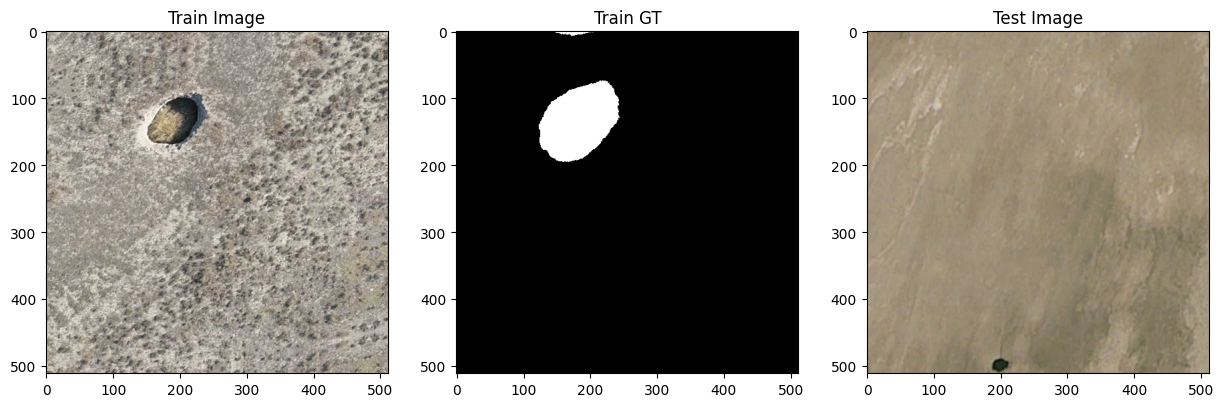

Train set: (906, 512, 512, 3) (906, 512, 512, 1)
Validation set: (48, 512, 512, 3) (48, 512, 512, 1)
Test set: (200, 512, 512, 3) (200, 512, 512, 1)


In [29]:
# Display a sample
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(X_train_rgb[2])
plt.title('Train Image')
plt.subplot(1, 3, 2)
plt.imshow(y_train[2].squeeze(), cmap='gray')
plt.title('Train GT')
plt.subplot(1, 3, 3)
plt.imshow(X_test_rgb[2])
plt.title('Test Image')
plt.show()

# Print shapes
print("Train set:", X_train_rgb.shape, y_train.shape)
print("Validation set:", X_val_rgb.shape, y_val.shape)
print("Test set:", X_test_rgb.shape, y_test.shape)


C:\ProgramData\Miniconda\envs\tf290\lib\site-packages\rasterio\__init__.py:333: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


⚠️ Skipping 000000000001 (2).tif: empty mask
⚠️ Skipping 000000000011 (10).tif: empty mask
⚠️ Skipping 000000000016 (7).tif: empty mask
⚠️ Skipping 000000000017 (2).tif: empty mask
⚠️ Skipping 000000000021 (6).tif: empty mask
⚠️ Skipping 000000000023 (5).tif: empty mask
⚠️ Skipping 000000000025 (7).tif: empty mask
⚠️ Skipping 000000000033 (5).tif: empty mask
⚠️ Skipping 000000000034 (2).tif: empty mask
⚠️ Skipping 000000000034 (3).tif: empty mask
⚠️ Skipping 000000000034 (5).tif: empty mask
⚠️ Skipping 000000000044 (5).tif: empty mask
⚠️ Skipping 000000000046 (5).tif: empty mask
⚠️ Skipping 000000000049.tif: empty mask
⚠️ Skipping 000000000052.tif: empty mask
⚠️ Skipping 000000000053.tif: empty mask
⚠️ Skipping 000000000055 (5).tif: empty mask
⚠️ Skipping 000000000060 (2).tif: empty mask
⚠️ Skipping 000000000060 (5).tif: empty mask
⚠️ Skipping 000000000060.tif: empty mask
⚠️ Skipping 000000000066.tif: empty mask
⚠️ Skipping 000000000074.tif: empty mask
⚠️ Skipping 000000000079 (2).tif:

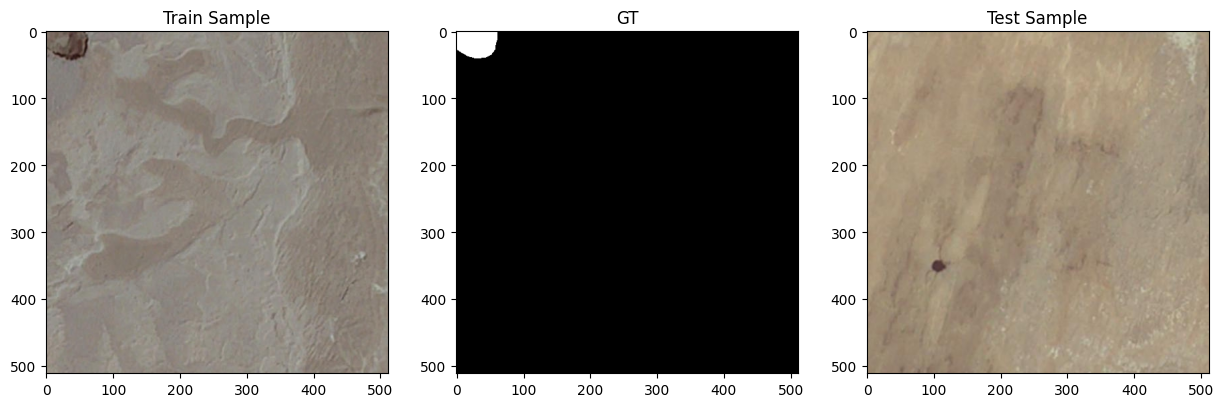

Train set: (488, 512, 512, 3) (488, 512, 512, 1)
Val set:   (26, 512, 512, 3) (26, 512, 512, 1)
Test set:  (416, 512, 512, 3) (416, 512, 512, 1)


In [11]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import random

def read_image(path):
    with rasterio.open(path) as src:
        img = src.read()
        img = np.moveaxis(img, 0, 2)
    return img[:, :, :3]

def read_mask(path):
    with rasterio.open(path) as src:
        mask = src.read(1)
    return mask[..., np.newaxis]

def get_valid_image_label_pairs(image_folder, label_folder):
    pairs = []
    for fname in os.listdir(label_folder):
        if fname.endswith('.tif'):
            label_path = os.path.join(label_folder, fname)
            image_path = os.path.join(image_folder, fname)
            if os.path.exists(image_path):
                mask = read_mask(label_path)
                if np.any(mask > 0):
                    pairs.append((image_path, label_path))
                else:
                    print(f"⚠️ Skipping {fname}: empty mask")
    return pairs

def load_dataset(pairs):
    images = [read_image(img) for img, _ in pairs]
    masks = [read_mask(lbl) for _, lbl in pairs]
    return np.stack(images), np.stack(masks)

def prepare_custom_split(image_folder, real_gt_folder, pseudo_gt_folder, num_samples=100, real_ratio=0.5):
    real_pairs = get_valid_image_label_pairs(image_folder, real_gt_folder)
    pseudo_pairs = get_valid_image_label_pairs(image_folder, pseudo_gt_folder)

    random.shuffle(real_pairs)
    random.shuffle(pseudo_pairs)

    num_real = int(real_ratio * num_samples)
    num_pseudo = num_samples - num_real

    selected_pairs = real_pairs[:num_real] + pseudo_pairs[:num_pseudo]
    random.shuffle(selected_pairs)

    X, y = load_dataset(selected_pairs)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42)

    return X_train, X_val, y_train, y_val

# === Parameters ===
num_samples = 514   #75 for 249 #30 for 100 
real_ratio = 1
test_limit = 1000  # Limit how many test samples to load (set None for all) #200 #300=800

# === Paths ===
image_folder = 'D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/images/'
real_gt_folder = 'D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/labels/'
pseudo_gt_folder = 'D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/output_of_final_model_second_pred_after_MC/'

X_train_rgb, X_val_rgb, y_train, y_val = prepare_custom_split(
    image_folder, real_gt_folder, pseudo_gt_folder,
    num_samples=num_samples,
    real_ratio=real_ratio
)

# === Load test set ===
test_rgb_folder = 'D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/images/'
test_gt_folder = 'D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/labels/'

test_rgb_paths = sorted([os.path.join(test_rgb_folder, f) for f in os.listdir(test_rgb_folder) if f.endswith('.tif')])
test_gt_paths = sorted([os.path.join(test_gt_folder, f) for f in os.listdir(test_gt_folder) if f.endswith('.tif')])

# === Apply test limit ===
if test_limit is not None:
    test_rgb_paths = test_rgb_paths[:test_limit]
    test_gt_paths = test_gt_paths[:test_limit]

X_test_rgb, y_test = [], []
for rgb, gt in zip(test_rgb_paths, test_gt_paths):
    mask = read_mask(gt)
    if np.any(mask > 0):
        X_test_rgb.append(read_image(rgb))
        y_test.append(mask)

X_test_rgb = np.stack(X_test_rgb)
y_test = np.stack(y_test)

# === Show Sample ===
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(X_train_rgb[0])
plt.title("Train Sample")

plt.subplot(1, 3, 2)
plt.imshow(y_train[0].squeeze(), cmap='gray')
plt.title("GT")

plt.subplot(1, 3, 3)
plt.imshow(X_test_rgb[0])
plt.title("Test Sample")

plt.show()

# === Stats ===
print("Train set:", X_train_rgb.shape, y_train.shape)
print("Val set:  ", X_val_rgb.shape, y_val.shape)
print("Test set: ", X_test_rgb.shape, y_test.shape)


import shutil

# === Output Folders ===
output_test_rgb = "D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/300_images/"
output_test_gt = "D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/300_labels/"
os.makedirs(output_test_rgb, exist_ok=True)
os.makedirs(output_test_gt, exist_ok=True)

# === Save the 200 selected RGB and GT files ===
print(f"💾 Saving {len(test_rgb_paths)} RGB images and GT masks...")

for src_img, src_mask in zip(test_rgb_paths, test_gt_paths):
    fname = os.path.basename(src_img)

    dst_img = os.path.join(output_test_rgb, fname)
    dst_mask = os.path.join(output_test_gt, fname)

    shutil.copyfile(src_img, dst_img)
    shutil.copyfile(src_mask, dst_mask)

print("✅ Done saving subset.")


In [12]:
import os
import numpy as np
from skimage.measure import label
from collections import defaultdict

# === Count connected sinkholes in a binary mask ===
def count_sinkholes(mask):
    binary = (mask.squeeze() > 0).astype(np.uint8)
    return label(binary, connectivity=1).max()

# === Setup stats ===
sinkhole_stats = {
    'Real': {'count': 0, 'files': []},
    'Pseudo': {'count': 0, 'files': []},
    'No_GT': {'count': 0, 'files': []},
    'Test': {'count': 0, 'files': []}
}

# === Parameters ===
real_cutoff = int(real_ratio * num_samples)
y_all = list(y_train) + list(y_val)

# === Process training/validation samples ===
for idx, mask in enumerate(y_all):
    num_sinkholes = count_sinkholes(mask)

    if num_sinkholes == 0:
        sinkhole_stats['No_GT']['count'] += 1
        sinkhole_stats['No_GT']['files'].append(f"sample_{idx}")
    else:
        label_type = 'Real' if idx < real_cutoff else 'Pseudo'
        sinkhole_stats[label_type]['count'] += num_sinkholes
        sinkhole_stats[label_type]['files'].append((f"sample_{idx}", num_sinkholes))

# === Process test set ===
for idx, mask in enumerate(y_test):
    num_sinkholes = count_sinkholes(mask)
    sinkhole_stats['Test']['count'] += num_sinkholes
    sinkhole_stats['Test']['files'].append((f"test_{idx}", num_sinkholes))

# === Summary ===
print(f"✅ Real samples with sinkholes:   {len(sinkhole_stats['Real']['files'])}, Total sinkholes: {sinkhole_stats['Real']['count']}")
print(f"✅ Pseudo samples with sinkholes: {len(sinkhole_stats['Pseudo']['files'])}, Total sinkholes: {sinkhole_stats['Pseudo']['count']}")
print(f"🚫 No-GT samples (empty masks):   {len(sinkhole_stats['No_GT']['files'])}")
print(f"📦 Test set samples:              {len(y_test)}, Total sinkholes: {sinkhole_stats['Test']['count']}")

# Optional: for inspection
sinkhole_stats_results = sinkhole_stats

✅ Real samples with sinkholes:   514, Total sinkholes: 1783
✅ Pseudo samples with sinkholes: 0, Total sinkholes: 0
🚫 No-GT samples (empty masks):   0
📦 Test set samples:              416, Total sinkholes: 989


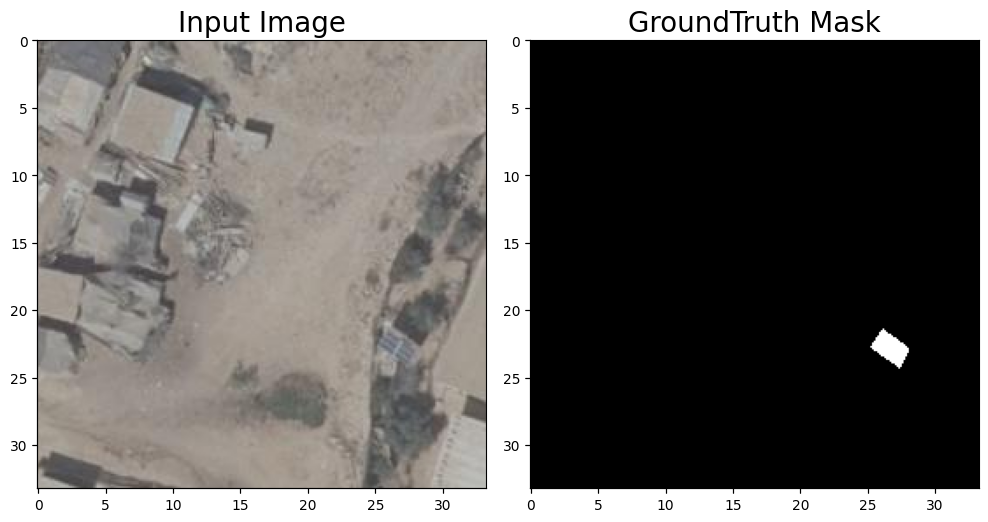

In [14]:
# Plot examples with refined ticks
resolution_cm = 13  # Define resolution in centimeters

def add_scale_marks(ax, pixel_size_cm):
    pixel_size_m = pixel_size_cm / 100.0
    spacing_m = 5  # Adjusted to 5 meter intervals

    x_spacing = spacing_m / pixel_size_m
    y_spacing = spacing_m / pixel_size_m

    x_ticks = np.arange(0, ax.get_xlim()[1], x_spacing)
    y_ticks = np.arange(0, ax.get_ylim()[0], y_spacing)

    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax2 = ax.secondary_yaxis('left')
    ax2.set_yticks(y_ticks)
    ax2.set_yticklabels(np.round(y_ticks * pixel_size_m).astype(int), fontsize=10)
    ax2.tick_params(right=False, left=True, labelleft=True, labelright=False)

    ax3 = ax.secondary_xaxis('bottom')
    ax3.set_xticks(x_ticks)
    ax3.set_xticklabels(np.round(x_ticks * pixel_size_m).astype(int), fontsize=10)
    ax3.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)

plt.figure(figsize=(10, 5))  # Adjusted figure size
ax1 = plt.subplot(1, 2, 1)  # Changed to 2 columns
ax1.imshow(X_train_rgb[0])
ax1.set_title('Input Image',fontsize=20)
add_scale_marks(ax1, resolution_cm)

ax2 = plt.subplot(1, 2, 2)  # Changed to 2 columns
ax2.imshow(y_train[0].squeeze(), cmap='gray')
ax2.set_title('GroundTruth Mask',fontsize=20)
add_scale_marks(ax2, resolution_cm)

plt.tight_layout()
plt.savefig('u-net_input.png', dpi=300)  # Save the plot as a PNG file at 300 dpi
plt.show()

In [6]:
#model_RGB.save('D:/Osher/ann_osher/U-NET_pannels/Models/effModel_2017_dice_50_epoch/')

C:\ProgramData\Miniconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


INFO:tensorflow:Assets written to: D:/Osher/ann_osher/U-NET_pannels/Models/effModel_2015_dice_50_epoch/assets


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Function to calculate GPU memory usage difference
def get_gpu_memory_usage():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            memory_info = tf.config.experimental.get_memory_info('GPU:0')  # Assuming using GPU 0
            return memory_info['current'] / (1024 ** 2)  # Convert from bytes to MB
        except RuntimeError as e:
            print(e)

# Define a custom callback to monitor GPU memory usage
class MemoryUsageCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        memory_usage = get_gpu_memory_usage()
        if memory_usage is not None:
            print(f"Epoch {epoch+1}: Model Memory Usage: {memory_usage:.2f} MB")
        else:
            print(f"Epoch {epoch+1}: Unable to retrieve memory usage.")

def conv_block(input_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.Conv2D(num_filters, kernel_size=(kernel_size, kernel_size), padding="same")(input_tensor)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    x = layers.Conv2D(num_filters, kernel_size=(kernel_size, kernel_size), padding="same")(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x

def upsample_block(input_tensor, skip_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters, kernel_size, batch_norm, dropout_rate)
    return x

def UNetOneHead(input_shape, num_classes=1, dropout_rate=0.0, batch_norm=True):
    FILTER_NUM = 32  # Number of filters for the first layer
    FILTER_SIZE = 3  # Size of the convolutional filter

    input_layer = layers.Input(input_shape, dtype=tf.float32)

    # Encoder
    conv1 = conv_block(input_layer, FILTER_NUM, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = conv_block(pool1, FILTER_NUM * 2, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = conv_block(pool2, FILTER_NUM * 4, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = conv_block(pool3, FILTER_NUM * 8, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)
    center = conv_block(pool4, FILTER_NUM * 16, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)

    # Decoder
    up4 = upsample_block(center, conv4, FILTER_NUM * 8, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up3 = upsample_block(up4, conv3, FILTER_NUM * 4, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up2 = upsample_block(up3, conv2, FILTER_NUM * 2, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up1 = upsample_block(up2, conv1, FILTER_NUM, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)

    # Final convolution
    output = layers.Conv2D(num_classes, kernel_size=(1, 1), activation='sigmoid')(up1)

    # Model
    model = models.Model(inputs=input_layer, outputs=output, name="UNetOneHead")
    model.summary()
    return model

# Define the input shape for the RGB input
input_shape = (512, 512, 3)

# Creating the model with one input shape
model = UNetOneHead(input_shape, num_classes=1)

if model is None:
    print("Model creation failed!")
else:
    print("Model created successfully!")

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    # Compile the model with binary crossentropy and IoU metric
    model.compile(optimizer=optimizer, loss=bce_loss, metrics=[iou_metric])

    # Add early stopping to stop training when validation loss stops improving
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=False)

    # Train the model without data augmentation and use memory callback
    history = model.fit(
        X_train_rgb, y_train,
        batch_size=8,
        validation_data=(X_val_rgb, y_val),
        epochs=50,
        callbacks=[early_stopping, MemoryUsageCallback()]
    )


In [112]:
import tensorflow as tf #Eff-Unet without supervision
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import backend as K

# === Define Conv Block ===
def conv_block(input_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(input_tensor)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    return x

# === Define Upsample Block ===
def upsample_block(input_tensor, skip_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters, kernel_size, batch_norm, dropout_rate)
    return x

# === Define Model ===
def UNetWithEfficientNetV2B0BackboneRGB(input_shape, num_classes=1, dropout_rate=0.0, batch_norm=True):
    FILTER_NUM = 16
    input_layer = layers.Input(input_shape, dtype=tf.float32)

    base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_tensor=input_layer)

    # Encoder skip connections
    conv1 = base_model.get_layer('stem_activation').output       # 256×256
    conv2 = base_model.get_layer('block2b_add').output           # 128×128
    conv3 = base_model.get_layer('block3b_add').output           # 64×64
    conv4 = base_model.get_layer('block4c_add').output           # 32×32
    center = base_model.get_layer('block6h_add').output          # 16×16

    # Decoder
    up4 = upsample_block(center, conv4, FILTER_NUM * 8, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up3 = upsample_block(up4, conv3, FILTER_NUM * 4, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up2 = upsample_block(up3, conv2, FILTER_NUM * 2, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up1 = upsample_block(up2, conv1, FILTER_NUM, batch_norm=batch_norm, dropout_rate=dropout_rate)

    final_upsample = layers.UpSampling2D((2, 2), interpolation='bilinear')(up1)
    main_output = layers.Conv2D(num_classes, 1, activation='sigmoid', name='main_output')(final_upsample)

    model = models.Model(inputs=input_layer, outputs=main_output)
    return model

# === Build Model ===
input_shape = (512, 512, 3)
model_RGB = UNetWithEfficientNetV2B0BackboneRGB(input_shape, num_classes=1)
model_RGB.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_1 (Rescaling)        (None, 512, 512, 3)  0           ['input_3[0][0]']                
                                                                                                  
 normalization_1 (Normalization  (None, 512, 512, 3)  0          ['rescaling_1[0][0]']            
 )                                                                                                
                                                                                            

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# === Define Conv Block ===
def conv_block(input_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(input_tensor)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    return x

# === Define Upsample Block ===
def upsample_block(input_tensor, skip_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters, kernel_size, batch_norm, dropout_rate)
    return x

# === Define U-Net with ResNet50 Encoder ===
def UNetWithResNet50Backbone(input_shape, num_classes=1, dropout_rate=0.0, batch_norm=True):
    FILTER_NUM = 16
    input_layer = layers.Input(shape=input_shape)

    base_model = ResNet50(weights="imagenet", include_top=False, input_tensor=input_layer)

    # Encoder skip connections
    conv1 = base_model.get_layer("conv1_relu").output               # 256×256
    conv2 = base_model.get_layer("conv2_block3_out").output         # 128×128
    conv3 = base_model.get_layer("conv3_block4_out").output         # 64×64
    conv4 = base_model.get_layer("conv4_block6_out").output         # 32×32
    center = base_model.get_layer("conv5_block3_out").output        # 16×16

    # Decoder
    up4 = upsample_block(center, conv4, FILTER_NUM * 8, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up3 = upsample_block(up4, conv3, FILTER_NUM * 4, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up2 = upsample_block(up3, conv2, FILTER_NUM * 2, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up1 = upsample_block(up2, conv1, FILTER_NUM, batch_norm=batch_norm, dropout_rate=dropout_rate)

    final_upsample = layers.UpSampling2D((2, 2), interpolation="bilinear")(up1)
    main_output = layers.Conv2D(num_classes, 1, activation="sigmoid", name="main_output")(final_upsample)

    model = models.Model(inputs=input_layer, outputs=main_output)
    return model
input_shape = (512, 512, 3)
model = UNetWithResNet50Backbone(input_shape)
model.summary()


In [120]:
import tensorflow as tf
from tensorflow.keras import layers, models
from classification_models.tfkeras import Classifiers

# === Define Conv Block ===
def conv_block(input_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(input_tensor)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    return x

# === Define Upsample Block ===
def upsample_block(input_tensor, skip_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters, kernel_size, batch_norm, dropout_rate)
    return x

def UNetWithResNet18Backbone(input_shape, num_classes=1, dropout_rate=0.0, batch_norm=True):
    FILTER_NUM = 16
    input_layer = layers.Input(shape=input_shape)

    ResNet18, _ = Classifiers.get('resnet18')
    base_model = ResNet18(input_tensor=input_layer, weights='imagenet', include_top=False)

    # Correct layer names based on model.summary()
    conv1 = base_model.get_layer("relu0").output                     # 256×256
    conv2 = base_model.get_layer("stage1_unit2_relu2").output        # 128×128
    conv3 = base_model.get_layer("stage2_unit2_relu2").output        # 64×64
    conv4 = base_model.get_layer("stage3_unit2_relu2").output        # 32×32
    center = base_model.get_layer("stage4_unit2_relu2").output       # 16×16

    # Decoder
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        if batch_norm: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same")(x)
        if batch_norm: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        if dropout_rate > 0: x = layers.Dropout(dropout_rate)(x)
        return x

    def upsample_block(x, skip, filters):
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip])
        return conv_block(x, filters)

    up4 = upsample_block(center, conv4, FILTER_NUM * 8)
    up3 = upsample_block(up4, conv3, FILTER_NUM * 4)
    up2 = upsample_block(up3, conv2, FILTER_NUM * 2)
    up1 = upsample_block(up2, conv1, FILTER_NUM)

    final_upsample = layers.UpSampling2D((2, 2), interpolation="bilinear")(up1)
    main_output = layers.Conv2D(num_classes, 1, activation="sigmoid", name="main_output")(final_upsample)

    model = models.Model(inputs=input_layer, outputs=main_output)
    return model

# === Build Model ===
input_shape = (512, 512, 3)
model = UNetWithResNet18Backbone(input_shape)
model.summary()


Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 bn_data (BatchNormalization)   (None, 512, 512, 3)  9           ['input_11[0][0]']               
                                                                                                  
 zero_padding2d_90 (ZeroPadding  (None, 518, 518, 3)  0          ['bn_data[0][0]']                
 2D)                                                                                              
                                                                                           

In [119]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

""" Atrous Spatial Pyramid Pooling """
def ASPP(inputs):
    shape = inputs.shape

    y_pool = AveragePooling2D(pool_size=(shape[1], shape[2]), name='average_pooling')(inputs)
    y_pool = Conv2D(filters=256, kernel_size=1, padding='same', use_bias=False)(y_pool)
    y_pool = BatchNormalization(name=f'bn_1')(y_pool)
    y_pool = Activation('relu', name=f'relu_1')(y_pool)
    y_pool = UpSampling2D((shape[1], shape[2]), interpolation="bilinear")(y_pool)

    y_1 = Conv2D(filters=256, kernel_size=1, dilation_rate=1, padding='same', use_bias=False)(inputs)
    y_1 = BatchNormalization()(y_1)
    y_1 = Activation('relu')(y_1)

    y_6 = Conv2D(filters=256, kernel_size=3, dilation_rate=6, padding='same', use_bias=False)(inputs)
    y_6 = BatchNormalization()(y_6)
    y_6 = Activation('relu')(y_6)

    y_12 = Conv2D(filters=256, kernel_size=3, dilation_rate=12, padding='same', use_bias=False)(inputs)
    y_12 = BatchNormalization()(y_12)
    y_12 = Activation('relu')(y_12)

    y_18 = Conv2D(filters=256, kernel_size=3, dilation_rate=18, padding='same', use_bias=False)(inputs)
    y_18 = BatchNormalization()(y_18)
    y_18 = Activation('relu')(y_18)

    y = Concatenate()([y_pool, y_1, y_6, y_12, y_18])

    y = Conv2D(filters=256, kernel_size=1, dilation_rate=1, padding='same', use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)
    return y

def DeepLabV3Plus(shape):
    """ Inputs """
    inputs = Input(shape)

    """ Pre-trained ResNet50 """
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)

    """ Pre-trained ResNet50 Output """
    image_features = base_model.get_layer('conv4_block6_out').output
    x_a = ASPP(image_features)
    x_a = UpSampling2D((4, 4), interpolation="bilinear")(x_a)

    """ Get low-level features """
    x_b = base_model.get_layer('conv2_block2_out').output
    x_b = Conv2D(filters=48, kernel_size=1, padding='same', use_bias=False)(x_b)
    x_b = BatchNormalization()(x_b)
    x_b = Activation('relu')(x_b)

    x = Concatenate()([x_a, x_b])

    x = Conv2D(filters=256, kernel_size=3, padding='same', activation='relu',use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters=256, kernel_size=3, padding='same', activation='relu', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((4, 4), interpolation="bilinear")(x)

    """ Outputs """
    x = Conv2D(1, (1, 1), name='output_layer')(x)
    x = Activation('sigmoid')(x)

    """ Model """
    model = Model(inputs=inputs, outputs=x)
    return model

input_shape = (512, 512, 3)
model = DeepLabV3Plus(input_shape)
model.summary()


Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 518, 518, 3)  0           ['input_10[0][0]']               
                                                                                                  
 conv1_conv (Conv2D)            (None, 256, 256, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, UpSampling2D, Concatenate, Input, AveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetV2B0


# === ASPP Module ===
def ASPP(inputs):
    shape = inputs.shape

    y_pool = AveragePooling2D(pool_size=(shape[1], shape[2]))(inputs)
    y_pool = Conv2D(256, 1, padding='same', use_bias=False)(y_pool)
    y_pool = BatchNormalization()(y_pool)
    y_pool = Activation('relu')(y_pool)
    y_pool = UpSampling2D((shape[1], shape[2]), interpolation="bilinear")(y_pool)

    y_1 = Conv2D(256, 1, dilation_rate=1, padding='same', use_bias=False)(inputs)
    y_1 = BatchNormalization()(y_1)
    y_1 = Activation('relu')(y_1)

    y_6 = Conv2D(256, 3, dilation_rate=6, padding='same', use_bias=False)(inputs)
    y_6 = BatchNormalization()(y_6)
    y_6 = Activation('relu')(y_6)

    y_12 = Conv2D(256, 3, dilation_rate=12, padding='same', use_bias=False)(inputs)
    y_12 = BatchNormalization()(y_12)
    y_12 = Activation('relu')(y_12)

    y_18 = Conv2D(256, 3, dilation_rate=18, padding='same', use_bias=False)(inputs)
    y_18 = BatchNormalization()(y_18)
    y_18 = Activation('relu')(y_18)

    y = Concatenate()([y_pool, y_1, y_6, y_12, y_18])
    y = Conv2D(256, 1, padding='same', use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    return y


# === DeepLabV3+ with EfficientNetV2B0 ===
def DeepLabV3Plus_EffNetV2B0(input_shape=(512, 512, 3)):
    inputs = Input(shape=input_shape)

    base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_tensor=inputs)

    # High-level features for ASPP
    x_high = base_model.get_layer('block6h_add').output  # (16x16)

    # Low-level features for decoder
    x_low = base_model.get_layer('block2b_add').output   # (64x64)

    # ASPP
    # ASPP
    x_a = ASPP(x_high)
    x_a = UpSampling2D((8, 8), interpolation='bilinear')(x_a)  # from 16×16 → 128×128
    
    # Low-level features (from earlier stage)
    x_b = base_model.get_layer('block2b_add').output  # 128×128
    x_b = Conv2D(48, 1, padding='same', use_bias=False)(x_b)
    x_b = BatchNormalization()(x_b)
    x_b = Activation('relu')(x_b)
    
    # Concatenate and continue
    x = Concatenate()([x_a, x_b])

    # Decoder convolution blocks
    x = Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Final upsampling to match input resolution
    x = UpSampling2D((4, 4), interpolation='bilinear')(x)  # (256x256 -> 512x512)

    # Output layer
    x = Conv2D(1, (1, 1), name='output_layer')(x)
    x = Activation('sigmoid')(x)

    model = Model(inputs=inputs, outputs=x)
    return model
input_shape = (512, 512, 3)
model = DeepLabV3Plus_EffNetV2B0(input_shape)
model.summary()

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from classification_models.tfkeras import Classifiers

def ASPP(inputs):
    input_shape = tf.shape(inputs)[1:3]
    y_pool = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    y_pool = layers.Reshape((1, 1, -1))(y_pool)
    y_pool = layers.Conv2D(256, 1, padding='same', use_bias=False)(y_pool)
    y_pool = layers.BatchNormalization()(y_pool)
    y_pool = layers.Activation('relu')(y_pool)
    y_pool = tf.image.resize(y_pool, size=(inputs.shape[1], inputs.shape[2]), method='bilinear')

    y_1 = layers.Conv2D(256, 1, dilation_rate=1, padding='same', use_bias=False)(inputs)
    y_1 = layers.BatchNormalization()(y_1)
    y_1 = layers.Activation('relu')(y_1)

    y_6 = layers.Conv2D(256, 3, dilation_rate=6, padding='same', use_bias=False)(inputs)
    y_6 = layers.BatchNormalization()(y_6)
    y_6 = layers.Activation('relu')(y_6)

    y_12 = layers.Conv2D(256, 3, dilation_rate=12, padding='same', use_bias=False)(inputs)
    y_12 = layers.BatchNormalization()(y_12)
    y_12 = layers.Activation('relu')(y_12)

    y_18 = layers.Conv2D(256, 3, dilation_rate=18, padding='same', use_bias=False)(inputs)
    y_18 = layers.BatchNormalization()(y_18)
    y_18 = layers.Activation('relu')(y_18)

    y = layers.Concatenate()([y_pool, y_1, y_6, y_12, y_18])
    y = layers.Conv2D(256, 1, padding='same', use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)
    return y

def DeepLabV3Plus_ResNet18(input_shape=(512, 512, 3), num_classes=1):
    ResNet18, _ = Classifiers.get('resnet18')
    base_model = ResNet18(input_shape=input_shape, weights='imagenet', include_top=False)

    low_level_feat = base_model.get_layer("stage1_unit2_relu2").output   # (128x128)
    high_level_feat = base_model.get_layer("stage4_unit2_relu2").output  # (16x16)

    x = ASPP(high_level_feat)
    x = layers.UpSampling2D(size=(8, 8), interpolation="bilinear")(x)  # → (128x128)

    low_level_feat = layers.Conv2D(48, 1, padding='same', use_bias=False)(low_level_feat)
    low_level_feat = layers.BatchNormalization()(low_level_feat)
    low_level_feat = layers.Activation('relu')(low_level_feat)

    x = layers.Concatenate()([x, low_level_feat])  # → (128x128)
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)  # → (512x512)

    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid")(x)
    return Model(inputs=base_model.input, outputs=outputs)

# Build model
model = DeepLabV3Plus_ResNet18(input_shape=(512, 512, 3))
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 bn_data (BatchNormalization)   (None, 512, 512, 3)  9           ['data[0][0]']                   
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 518, 518, 3)  0          ['bn_data[0][0]']                
                                                                                                  
 conv0 (Conv2D)                 (None, 256, 256, 64  9408        ['zero_padding2d[0][0]']   

In [99]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D, Concatenate, Input
from tensorflow.keras.models import Model

# === Atrous Spatial Pyramid Pooling ===
def ASPP(inputs):
    shape = inputs.shape

    y_pool = AveragePooling2D(pool_size=(shape[1], shape[2]))(inputs)
    y_pool = Conv2D(256, 1, padding='same', use_bias=False)(y_pool)
    y_pool = BatchNormalization()(y_pool)
    y_pool = Activation('relu')(y_pool)
    y_pool = UpSampling2D((shape[1], shape[2]), interpolation="bilinear")(y_pool)

    y_1 = Conv2D(256, 1, dilation_rate=1, padding='same', use_bias=False)(inputs)
    y_1 = BatchNormalization()(y_1)
    y_1 = Activation('relu')(y_1)

    y_6 = Conv2D(256, 3, dilation_rate=6, padding='same', use_bias=False)(inputs)
    y_6 = BatchNormalization()(y_6)
    y_6 = Activation('relu')(y_6)

    y_12 = Conv2D(256, 3, dilation_rate=12, padding='same', use_bias=False)(inputs)
    y_12 = BatchNormalization()(y_12)
    y_12 = Activation('relu')(y_12)

    y_18 = Conv2D(256, 3, dilation_rate=18, padding='same', use_bias=False)(inputs)
    y_18 = BatchNormalization()(y_18)
    y_18 = Activation('relu')(y_18)

    y = Concatenate()([y_pool, y_1, y_6, y_12, y_18])
    y = Conv2D(256, 1, padding='same', use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)
    return y

# === Simple Conv Block ===
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

# === Build DeepLabV3+ from Scratch ===
def DeepLabV3PlusScratch(input_shape):
    inputs = Input(shape=input_shape)

    # Encoder - custom downsampling path
    x = conv_block(inputs, 64)
    x = MaxPooling2D((2, 2))(x)           # 256x256

    x = conv_block(x, 128)
    x_low = x                             # Low-level feature for skip connection
    x = MaxPooling2D((2, 2))(x)           # 128x128

    x = conv_block(x, 256)
    x = MaxPooling2D((2, 2))(x)           # 64x64

    x = conv_block(x, 512)
    x = MaxPooling2D((2, 2))(x)           # 32x32

    # ASPP at bottleneck
    x = ASPP(x)
    x = UpSampling2D((8, 8), interpolation="bilinear")(x)
    # Decoder
    x_low = Conv2D(48, 1, padding='same', use_bias=False)(x_low)
    x_low = BatchNormalization()(x_low)
    x_low = Activation('relu')(x_low)

    x = Concatenate()([x, x_low])
    x = conv_block(x, 256)

    x = UpSampling2D((2, 2), interpolation="bilinear")(x)
    # Output
    outputs = Conv2D(1, 1, activation='sigmoid', name='output_layer')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (512, 512, 3)
model = DeepLabV3PlusScratch(input_shape)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 64  1728        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 512, 512, 64  256        ['conv2d[0][0]']                 
 alization)                     )                                                             

In [9]:
# === Compile ===  ##first training loop
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=dice_loss,
    metrics=[iou_metric]
)

# === Callbacks ===
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=50, restore_best_weights=False
)

# === Train ===
history = model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    batch_size=8,
    epochs=16,
    callbacks=[early_stopping]
)

Epoch 1/16
61/61 [==============================] - 16s 224ms/step - loss: 0.2307 - iou_metric: 0.6341 - val_loss: 0.6363 - val_iou_metric: 0.2994
Epoch 2/16
61/61 [==============================] - 13s 215ms/step - loss: 0.2699 - iou_metric: 0.5825 - val_loss: 0.8037 - val_iou_metric: 0.1397
Epoch 3/16
61/61 [==============================] - 13s 216ms/step - loss: 0.2157 - iou_metric: 0.6511 - val_loss: 0.5324 - val_iou_metric: 0.3474
Epoch 4/16
61/61 [==============================] - 13s 218ms/step - loss: 0.1721 - iou_metric: 0.7092 - val_loss: 0.3751 - val_iou_metric: 0.5192
Epoch 5/16
61/61 [==============================] - 13s 220ms/step - loss: 0.1646 - iou_metric: 0.7207 - val_loss: 0.4388 - val_iou_metric: 0.4606
Epoch 6/16
61/61 [==============================] - 14s 222ms/step - loss: 0.1928 - iou_metric: 0.6809 - val_loss: 0.4246 - val_iou_metric: 0.4668
Epoch 7/16
61/61 [==============================] - 14s 223ms/step - loss: 0.1747 - iou_metric: 0.7080 - val_loss: 0.3

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import backend as K

# === Step 1: Build model ===
model_full = UNetWithEfficientNetV2B0BackboneRGB(
    input_shape=(512, 512, 3),
    num_classes=1,
    dropout_rate=0.1
)

# === Step 2: Load pretrained weights ===
model_full.load_weights('D:/Osher/ISPRS_AUTOSINK1/new_models/new_models_models0.5_1797lables_100%ps_final_mc/')

# === Step 3: Make all layers trainable ===
for layer in model_full.layers:
    layer.trainable = True

print("✅ All layers set to trainable.")

# === Step 4: Compile model ===
model_full.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-7),  # same final LR from staged training
    loss=bce_loss,  # same loss as final stage
    metrics=[iou_metric]
)

# === Step 5: Define callbacks ===
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=False
)

# === Step 6: Train the full model ===
print("🚀 Training full model (no freezing)...")
model_full.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    batch_size=8,
    epochs=30,  # 10+10+10 from your previous staged setup
    callbacks=[early_stopping]
)

# === Summary ===
trainable_params = np.sum([K.count_params(w) for w in model_full.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model_full.non_trainable_weights])
print(f"\n📊 Final trainable params: {trainable_params:,}")
print(f"📊 Final non-trainable params: {non_trainable_params:,}")


In [ ]:
model_RGB.summary()

In [ ]:
import tensorflow as tf #supervision
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import backend as K


def conv_block(input_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(input_tensor)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(num_filters, kernel_size, padding="same")(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    return x

def upsample_block(input_tensor, skip_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters, kernel_size, batch_norm, dropout_rate)
    return x

def UNetWithEfficientNetV2B0BackboneRGB(input_shape, num_classes=1, dropout_rate=0.0, batch_norm=True):
    FILTER_NUM = 16
    input_layer = layers.Input(input_shape, dtype=tf.float32)

    base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_tensor=input_layer)

    # Updated skip connections for EfficientNetV2B0
    conv1 = base_model.get_layer('stem_activation').output       # 256×256
    conv2 = base_model.get_layer('block2b_add').output           # 128×128
    conv3 = base_model.get_layer('block3b_add').output           # 64×64
    conv4 = base_model.get_layer('block4c_add').output           # 32×32
    center = base_model.get_layer('block6h_add').output          # 16×16

    # Decoder path
    up4 = upsample_block(center, conv4, FILTER_NUM * 8, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up3 = upsample_block(up4, conv3, FILTER_NUM * 4, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up2 = upsample_block(up3, conv2, FILTER_NUM * 2, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up1 = upsample_block(up2, conv1, FILTER_NUM, batch_norm=batch_norm, dropout_rate=dropout_rate)

    final_upsample = layers.UpSampling2D((2, 2), interpolation='bilinear')(up1)
    main_output = layers.Conv2D(num_classes, 1, activation='sigmoid', name='main_output')(final_upsample)

    aux_output1 = layers.Conv2D(num_classes, 1, activation='sigmoid', name='aux_output1')(up2)
    aux_output1 = layers.UpSampling2D((4, 4), interpolation='bilinear')(aux_output1)

    aux_output2 = layers.Conv2D(num_classes, 1, activation='sigmoid', name='aux_output2')(up3)
    aux_output2 = layers.UpSampling2D((8, 8), interpolation='bilinear')(aux_output2)

    model = models.Model(inputs=input_layer, outputs=[main_output, aux_output1, aux_output2])
    return model


input_shape = (512, 512, 3)
model_RGB = UNetWithEfficientNetV2B0BackboneRGB(input_shape, num_classes=1)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model_RGB.compile(
    optimizer=optimizer,
    loss=weighted_dice_loss, #dice best  ##weighted_dice_loss 0.5
    metrics=[iou_metric]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=25, restore_best_weights=False
)

history = model_RGB.fit(
    X_train_rgb, [y_train, y_train, y_train],
    validation_data=(X_val_rgb, [y_val, y_val, y_val]),
    batch_size=8, epochs=50, callbacks=[early_stopping]
)


In [94]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# === Flatten all GT and prediction probabilities ===
all_gt_pixels = []
all_pred_pixels = []

for i in range(len(X_test_rgb)):
    y_true = y_test[i].squeeze().flatten()
    y_pred_prob = model_RGB.predict(X_test_rgb[i:i+1])[0].squeeze().flatten()

    if np.sum(y_true) < 50:
        continue

    all_gt_pixels.append(y_true)
    all_pred_pixels.append(y_pred_prob)

all_gt_pixels = np.concatenate(all_gt_pixels)
all_pred_pixels = np.concatenate(all_pred_pixels)

# === Compute ROC and PR curves ===
fpr, tpr, _ = roc_curve(all_gt_pixels, all_pred_pixels)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(all_gt_pixels, all_pred_pixels)
pr_auc = auc(recall, precision)

# === Plot ===
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 45ms/step


KeyboardInterrupt: 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# === Metric Functions ===
def calculate_foreground_iou(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    y_true_fg = (y_true == 1).astype(np.float32)
    y_pred_fg = (y_pred == 1).astype(np.float32)
    intersection = np.sum(y_true_fg * y_pred_fg)
    union = np.sum(y_true_fg) + np.sum(y_pred_fg) - intersection
    return intersection / union if union != 0 else 0

def calculate_iou(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + 1e-7)

def calculate_dice(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

# === Predict on Test Set ===
predictions = model.predict(X_test_rgb, batch_size=8)
predictions_binary = (predictions > 0.5).astype(np.uint8)

# === Metric Aggregation ===
ious, precisions, recalls, f1s, accuracies, dices = [], [], [], [], [], []
tprs, fprs, specificities, balanced_accuracies, fnrs, mccs = [], [], [], [], [], []

for i in range(len(X_test_rgb)):
    y_true = y_test[i].flatten()
    y_pred = predictions_binary[i].flatten()

    if np.sum(y_true) < 50:
        continue

    iou = calculate_foreground_iou(y_test[i], predictions_binary[i])
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    dice = calculate_dice(y_test[i], predictions_binary[i])

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    cm = np.pad(cm, (0, max(0, 4 - len(cm))), mode='constant')
    tn, fp, fn, tp = cm[:4]

    tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    balanced_acc = (tpr + specificity) / 2
    fnr = fn / (fn + tp) if (fn + tp) != 0 else 0

    denom_terms = [tp + fp, tp + fn, tn + fp, tn + fn]
    if all(term != 0 for term in denom_terms):
        try:
            denom = np.sqrt(np.prod(denom_terms, dtype=np.float64))
            mcc = ((tp * tn) - (fp * fn)) / denom if denom != 0 else 0
        except (OverflowError, FloatingPointError):
            mcc = 0
    else:
        mcc = 0

    # Append metrics
    ious.append(iou)
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(accuracy)
    dices.append(dice)
    tprs.append(tpr)
    fprs.append(fpr)
    specificities.append(specificity)
    balanced_accuracies.append(balanced_acc)
    fnrs.append(fnr)
    mccs.append(mcc)

# === Basic Print ===
print(f"Mean IoU:           {np.mean(ious):.4f}")
print(f"Mean Precision:     {np.mean(precisions):.4f}")
print(f"Mean Recall:        {np.mean(recalls):.4f}")
print(f"Mean F1 Score:      {np.mean(f1s):.4f}")
print(f"Mean Accuracy:      {np.mean(accuracies) * 100:.2f}%")
print(f"Mean Dice:          {np.mean(dices):.4f}")
print(f"Mean TPR:           {np.mean(tprs):.4f}")
print(f"Mean FPR:           {np.mean(fprs):.4f}")

# === Full Summary ===
print("\n📊 Evaluation Summary (only patches with >50 foreground pixels):")
print(f"Mean IoU:               {np.mean(ious):.4f}")
print(f"Mean Precision:         {np.mean(precisions):.4f}")
print(f"Mean Recall:            {np.mean(recalls):.4f}")
print(f"Mean F1 Score:          {np.mean(f1s):.4f}")
print(f"Mean Accuracy:          {np.mean(accuracies) * 100:.2f}%")
print(f"Mean Dice:              {np.mean(dices):.4f}")
print(f"Mean TPR (Sensitivity): {np.mean(tprs):.4f}")
print(f"Mean FPR:               {np.mean(fprs):.4f}")
print(f"Mean Specificity:       {np.mean(specificities):.4f}")
print(f"Mean Balanced Accuracy: {np.mean(balanced_accuracies):.4f}")
print(f"Mean FNR:               {np.mean(fnrs):.4f}")
print(f"Mean MCC:               {np.mean(mccs):.4f}")

38/38 [==============================] - 3s 75ms/step
Mean IoU:           0.4755
Mean Precision:     0.6166
Mean Recall:        0.6320
Mean F1 Score:      0.5766
Mean Accuracy:      97.11%
Mean Dice:          0.5766
Mean TPR:           0.6320
Mean FPR:           0.0098

📊 Evaluation Summary (only patches with >50 foreground pixels):
Mean IoU:               0.4755
Mean Precision:         0.6166
Mean Recall:            0.6320
Mean F1 Score:          0.5766
Mean Accuracy:          97.11%
Mean Dice:              0.5766
Mean TPR (Sensitivity): 0.6320
Mean FPR:               0.0098
Mean Specificity:       0.9902
Mean Balanced Accuracy: 0.8111
Mean FNR:               0.3680
Mean MCC:               0.5857


In [ ]:
import os
import numpy as np
import tifffile as tiff
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import random

# === Paths ===
gt_folder = "D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/300_labels/"
pred_folder = "D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/"

# === Metric Functions ===
def calculate_foreground_iou(y_true, y_pred):
    y_true_fg = (y_true == 1).astype(np.float32)
    y_pred_fg = (y_pred == 1).astype(np.float32)
    intersection = np.sum(y_true_fg * y_pred_fg)
    union = np.sum(y_true_fg) + np.sum(y_pred_fg) - intersection
    return intersection / union if union != 0 else 0

def calculate_dice(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

# === Initialize Metrics Lists ===
ious, precisions, recalls, f1s, accuracies, dices = [], [], [], [], [], []
tprs, fprs, specificities, balanced_accuracies, fnrs, mccs = [], [], [], [], [], []
examples = []  # collect a few examples to plot later

# === Load and Evaluate ===
filenames = sorted([f for f in os.listdir(gt_folder) if f.endswith(".tif")])
print(f"🔍 Evaluating {len(filenames)} patches...")

for fname in filenames:
    gt_path = os.path.join(gt_folder, fname)
    pred_path = os.path.join(pred_folder, fname)

    if not os.path.exists(pred_path):
        print(f"⚠️ Missing prediction for {fname}, skipping.")
        continue

    gt = tiff.imread(gt_path).astype(np.uint8)
    pred = tiff.imread(pred_path).astype(np.uint8)

    # Binary threshold
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    if np.sum(gt) < 50:
        continue

    y_true = gt.flatten()
    y_pred = pred.flatten()

    iou = calculate_foreground_iou(gt, pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    dice = calculate_dice(gt, pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    cm = np.pad(cm, (0, max(0, 4 - len(cm))), mode='constant')
    tn, fp, fn, tp = cm[:4]

    tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    balanced_acc = (tpr + specificity) / 2
    fnr = fn / (fn + tp) if (fn + tp) != 0 else 0

    denom_terms = [tp + fp, tp + fn, tn + fp, tn + fn]
    if all(term != 0 for term in denom_terms):
        denom = np.sqrt(np.prod(denom_terms, dtype=np.float64))
        mcc = ((tp * tn) - (fp * fn)) / denom if denom != 0 else 0
    else:
        mcc = 0

    # Append
    ious.append(iou)
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(accuracy)
    dices.append(dice)
    tprs.append(tpr)
    fprs.append(fpr)
    specificities.append(specificity)
    balanced_accuracies.append(balanced_acc)
    fnrs.append(fnr)
    mccs.append(mcc)

    # Collect a few random examples
    if len(examples) < 30 and random.random() < 0.1:
        examples.append((fname, gt, pred))

# === Summary ===
print("\n📊 Evaluation Summary (only patches with >50 foreground pixels):")
print(f"Mean IoU:               {np.mean(ious):.4f}")
print(f"Mean Precision:         {np.mean(precisions):.4f}")
print(f"Mean Recall:            {np.mean(recalls):.4f}")
print(f"Mean F1 Score:          {np.mean(f1s):.4f}")
print(f"Mean Accuracy:          {np.mean(accuracies) * 100:.2f}%")
print(f"Mean Dice:              {np.mean(dices):.4f}")
print(f"Mean TPR (Sensitivity): {np.mean(tprs):.4f}")
print(f"Mean FPR:               {np.mean(fprs):.4f}")
print(f"Mean Specificity:       {np.mean(specificities):.4f}")
print(f"Mean Balanced Accuracy: {np.mean(balanced_accuracies):.4f}")
print(f"Mean FNR:               {np.mean(fnrs):.4f}")
print(f"Mean MCC:               {np.mean(mccs):.4f}")

# === Plot Examples ===
print("\n🖼️ Showing sample patches...")
for fname, gt, pred in examples:
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(gt, cmap='gray')
    axs[0].set_title(f"GT: {fname}")
    axs[0].axis("off")
    axs[1].imshow(pred, cmap='gray')
    axs[1].set_title("Prediction")
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()


In [46]:
import numpy as np
import os
import tifffile as tiff
from tqdm import tqdm

# === Paths ===
image_folder = "D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/300_images/"
output_folder = "D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/"
os.makedirs(output_folder, exist_ok=True)

# === Load filenames ===
test_filenames = sorted([f for f in os.listdir(image_folder) if f.endswith(".tif")])

# === Parameters ===
BATCH_SIZE = 4

# === Predict and Save in Batches ===
print("🔄 Predicting and saving in batches...")
for i in tqdm(range(0, len(test_filenames), BATCH_SIZE), desc="📤 Batching"):
    batch_filenames = test_filenames[i:i+BATCH_SIZE]
    batch_images = []

    for fname in batch_filenames:
        img_path = os.path.join(image_folder, fname)
        image = tiff.imread(img_path)

        # Normalize and preprocess
        if image.dtype == np.uint16:
            image = (image / 65535.0).astype(np.float32)
        if len(image.shape) == 2:
            image = np.stack([image] * 3, axis=-1)
        elif image.shape[-1] > 3:
            image = image[..., :3]

        batch_images.append(image)

    batch_images_np = np.array(batch_images)

    # Predict
    batch_preds = model_RGB.predict(batch_images_np)
    batch_preds_bin = (batch_preds > 0.5).astype(np.uint8)

    # Save each prediction
    for j, fname in enumerate(batch_filenames):
        mask = batch_preds_bin[j]

        # (512, 512, 1) → (512, 512)
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask[:, :, 0]

        save_path = os.path.join(output_folder, fname)
        tiff.imwrite(save_path, mask.astype(np.uint8))
        print(f"✅ Saved: {save_path}")


🔄 Predicting and saving in batches...


📤 Batching:   0%|                                                                              | 0/75 [00:00<?, ?it/s]

1/1 [==============================] - 0s 53ms/step
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000000 (2).tif


📤 Batching:   1%|▉                                                                     | 1/75 [00:00<00:43,  1.70it/s]

✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000000 (3).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000000 (4).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000000 (5).tif
1/1 [==============================] - 0s 53ms/step


...

✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000065 (2).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000065 (3).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000065.tif
1/1 [==============================] - 0s 49ms/step
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000066 (2).tif


📤 Batching:  99%|████████████████████████████████████████████████████████████████████ | 74/75 [00:15<00:00,  4.78it/s]

✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000066 (3).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000066.tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000067 (2).tif
1/1 [==============================] - 0s 51ms/step


📤 Batching: 100%|█████████████████████████████████████████████████████████████████████| 75/75 [00:15<00:00,  4.92it/s]

✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000067 (3).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000067.tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000068 (2).tif
✅ Saved: D:/Osher/ISPRS_AUTOSINK1/test_data/test_meged/test_weird_after_restart2/000000000068 (3).tif


In [25]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === Paths ===
image_folder = "D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/images/"
mask_folder = "D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/pred_eff_raw/"
output_image_folder = "D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/aug_images_keras/"
output_mask_folder = "D:/Osher/ISPRS_AUTOSINK1/train_data/train_merged/aug_masks_keras/"
os.makedirs(output_image_folder, exist_ok=True)
os.makedirs(output_mask_folder, exist_ok=True)

# === Parameters ===
IMG_SIZE = (512, 512)
AUG_PER_IMAGE = 3
SEED = 42

# === Define Augmentation Generator ===
datagen_args = dict(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=70,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

image_datagen = ImageDataGenerator(**datagen_args)
mask_datagen = ImageDataGenerator(**datagen_args)

# === Process Images ===
image_filenames = sorted([f for f in os.listdir(image_folder) if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))])

print("🧪 Augmenting using ImageDataGenerator with synchronization...")
for fname in tqdm(image_filenames):
    base_name = os.path.splitext(fname)[0]
    img_path = os.path.join(image_folder, fname)
    mask_path = os.path.join(mask_folder, base_name + ".tif")

    # Load and resize image and mask
    image = cv2.imread(img_path)
    image = cv2.resize(image, IMG_SIZE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, IMG_SIZE)

    image = np.expand_dims(image, axis=0)
    mask = np.expand_dims(mask, axis=0)
    mask = np.expand_dims(mask, axis=-1)  # Add channel for compatibility

    # Use the same seed to ensure same transformation
    image_gen = image_datagen.flow(image, batch_size=1, seed=SEED)
    mask_gen = mask_datagen.flow(mask, batch_size=1, seed=SEED)

    for i in range(AUG_PER_IMAGE):
        aug_img = image_gen.next()[0].astype(np.uint8)
        aug_mask = mask_gen.next()[0, :, :, 0].astype(np.uint8)  # Remove extra channel

        img_out_path = os.path.join(output_image_folder, f"{base_name}_aug{i+1}.tif")
        mask_out_path = os.path.join(output_mask_folder, f"{base_name}_aug{i+1}.tif")

        cv2.imwrite(img_out_path, aug_img)
        cv2.imwrite(mask_out_path, aug_mask)

print(f"\n✅ Augmented {len(image_filenames)} image–mask pairs × {AUG_PER_IMAGE} using Keras' ImageDataGenerator.")


🧪 Augmenting using ImageDataGenerator with synchronization...


100%|███████████████████████████████████████████████████████████████████████████████| 514/514 [02:49<00:00,  3.04it/s]


✅ Augmented 514 image–mask pairs × 3 using Keras' ImageDataGenerator.


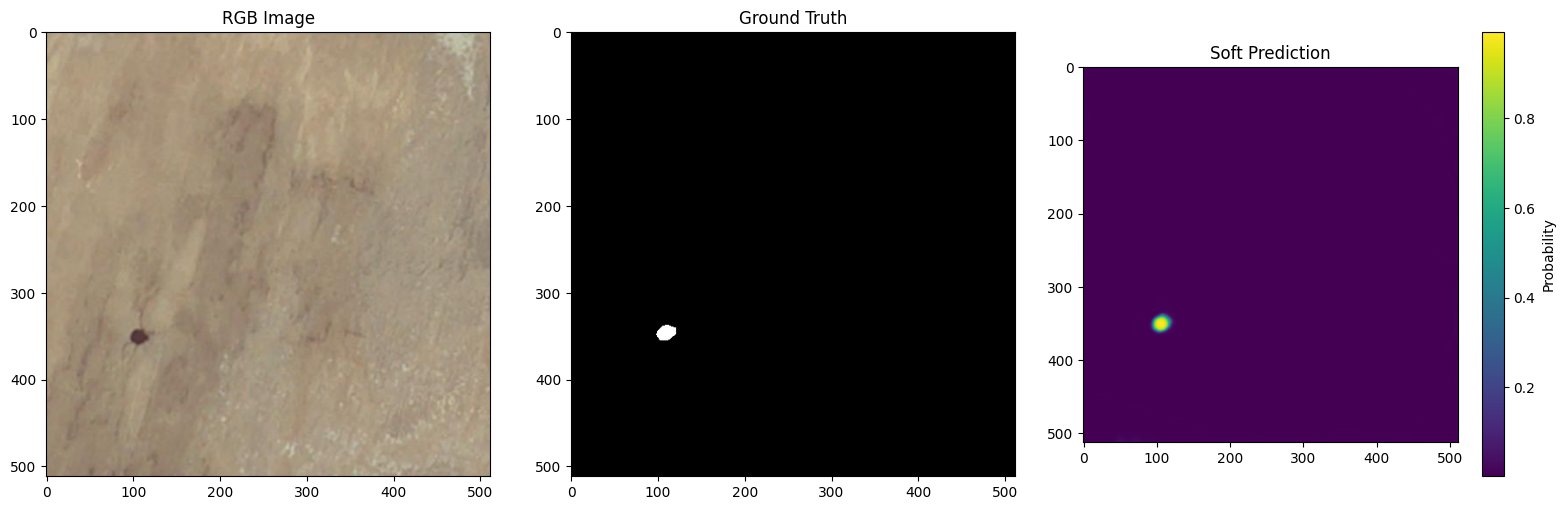

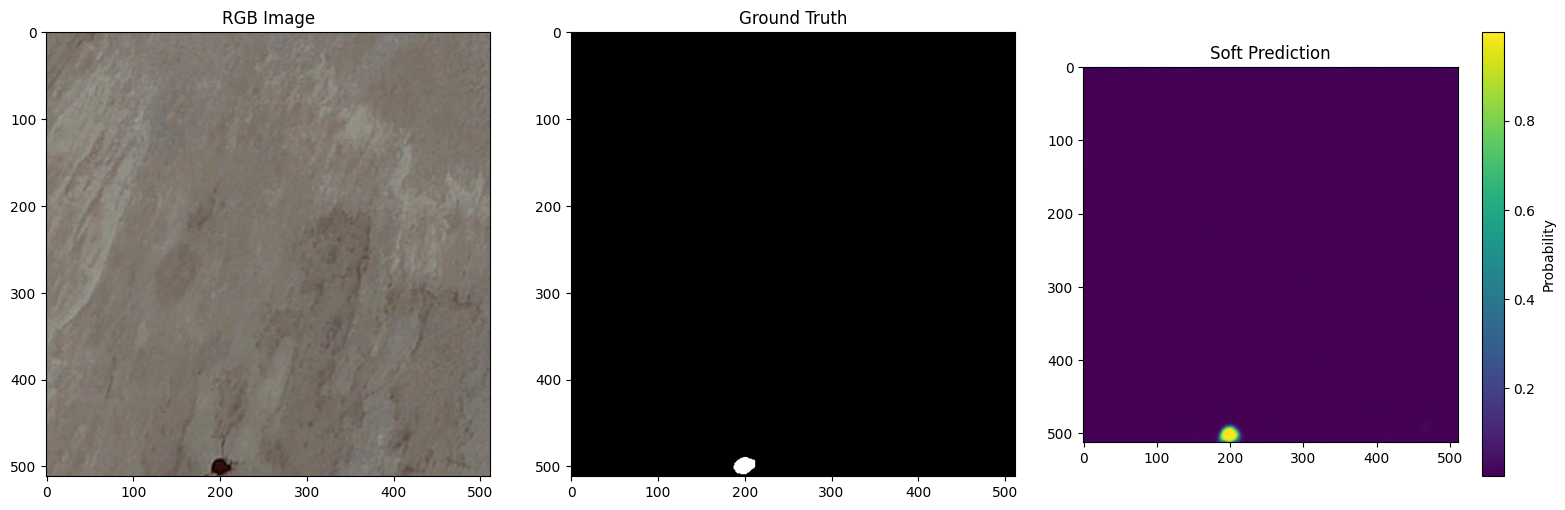

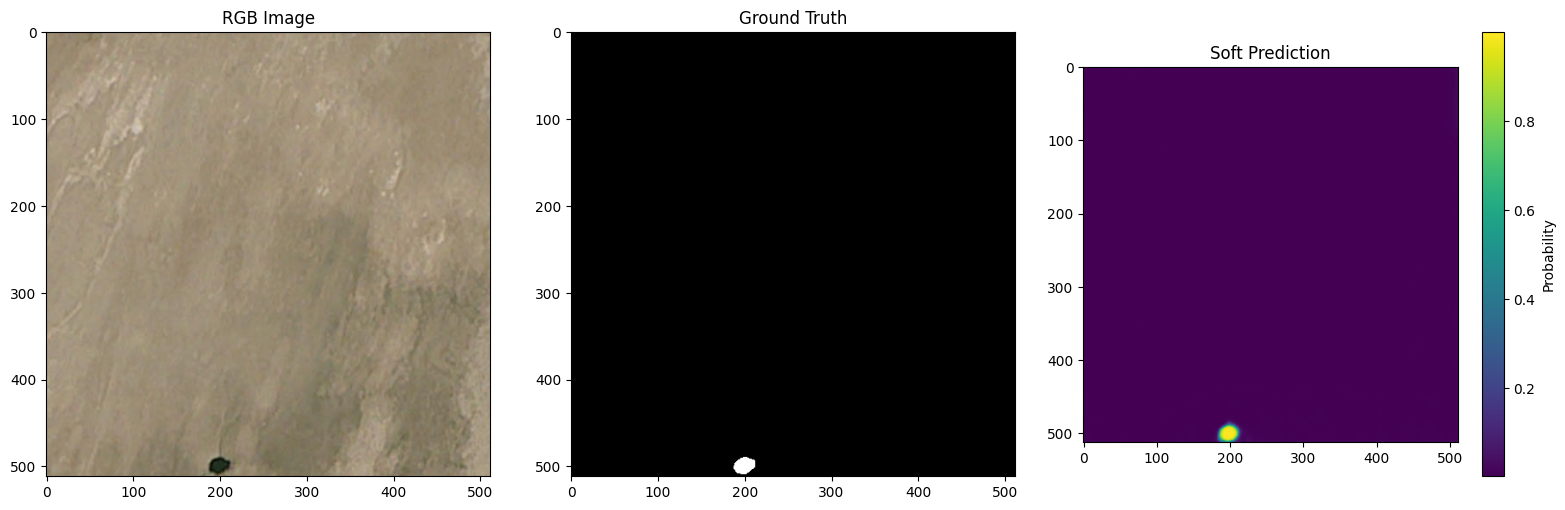

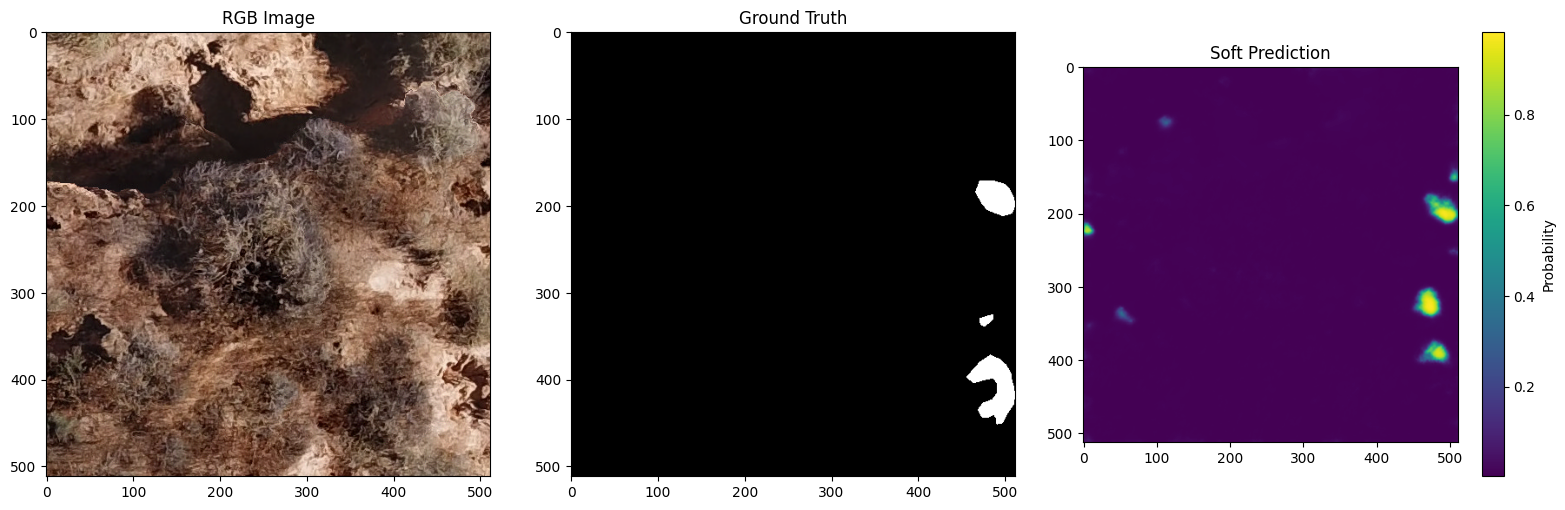

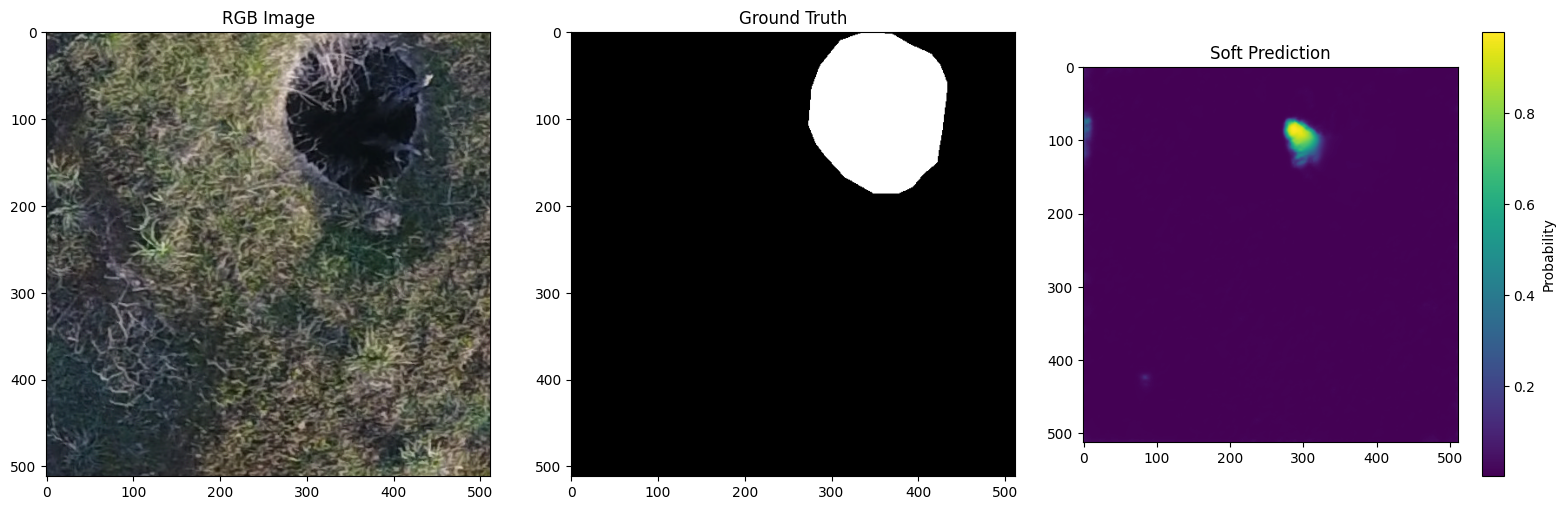

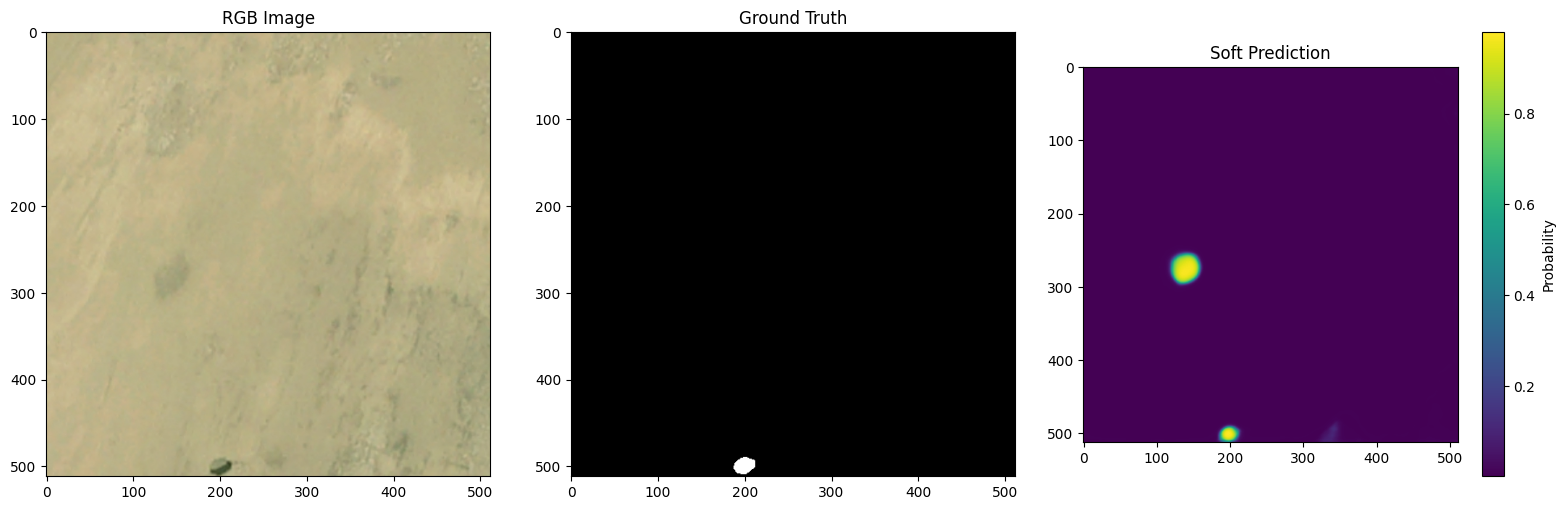

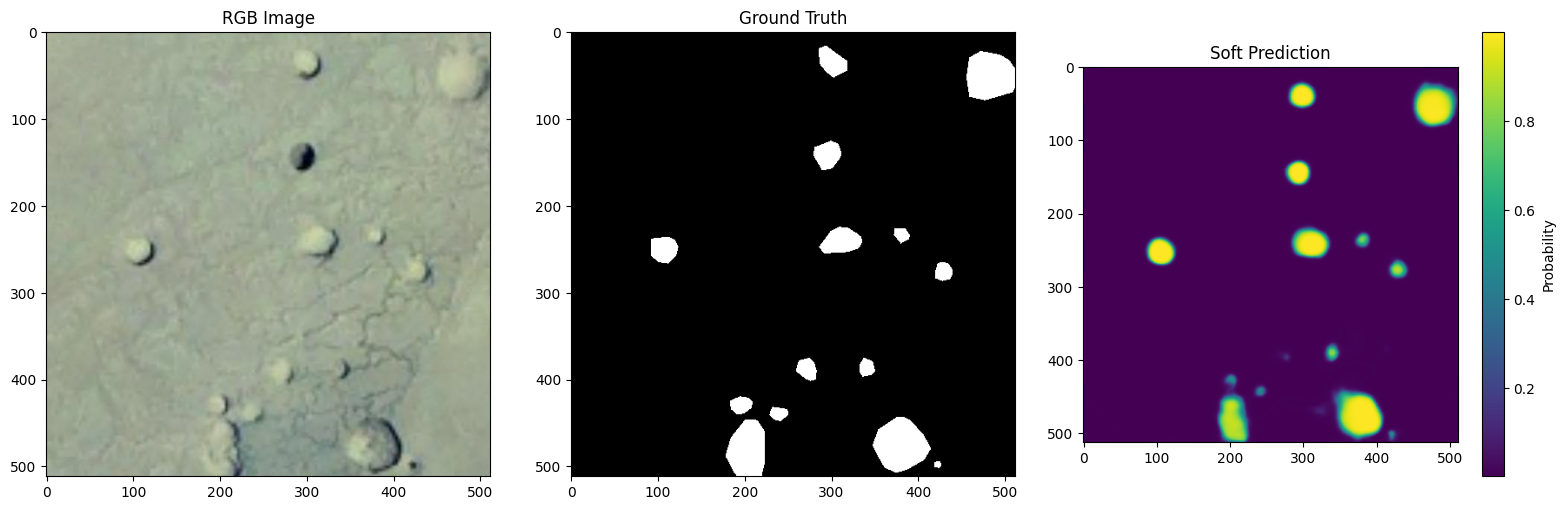

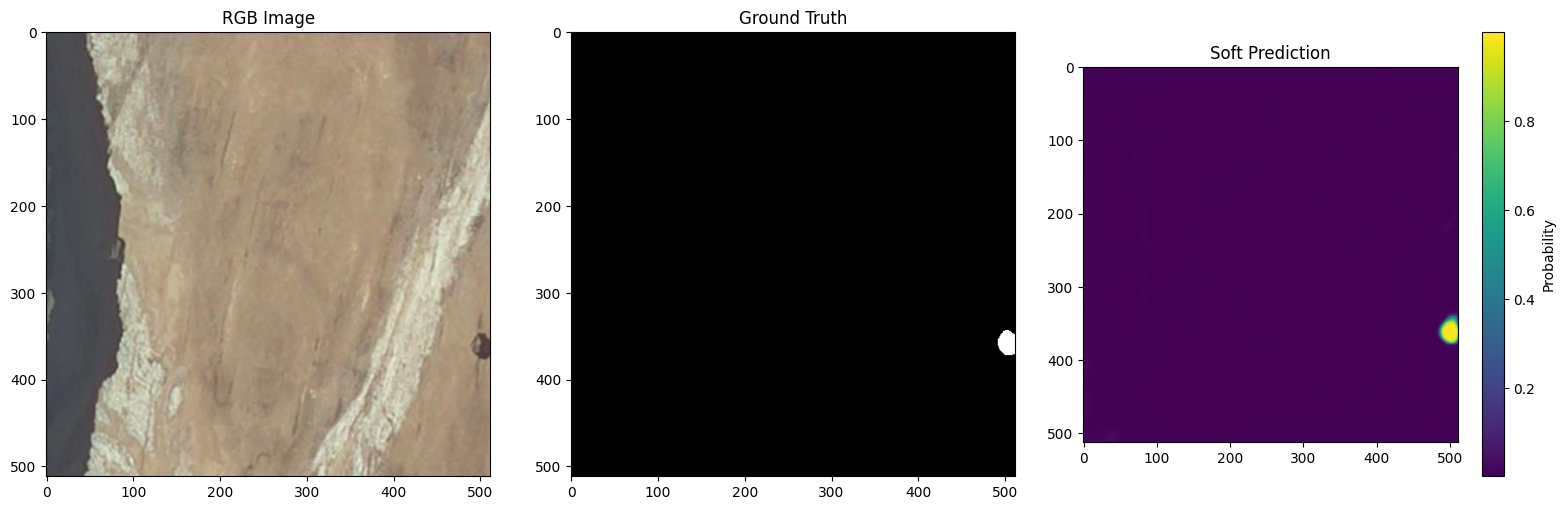

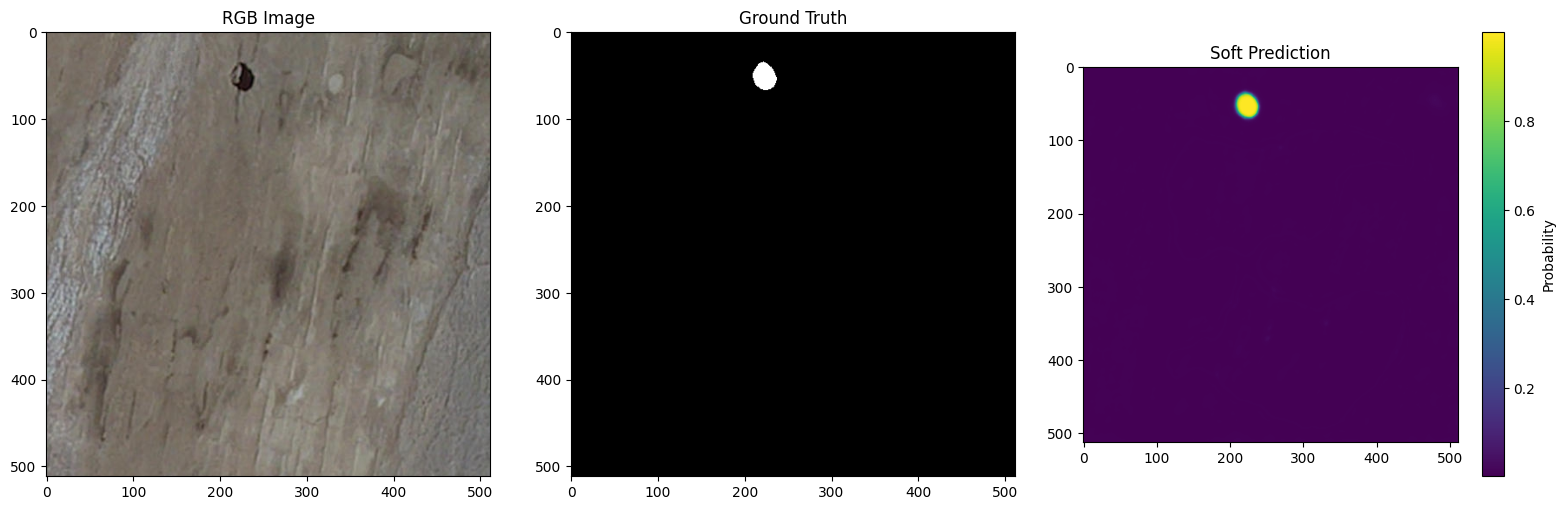

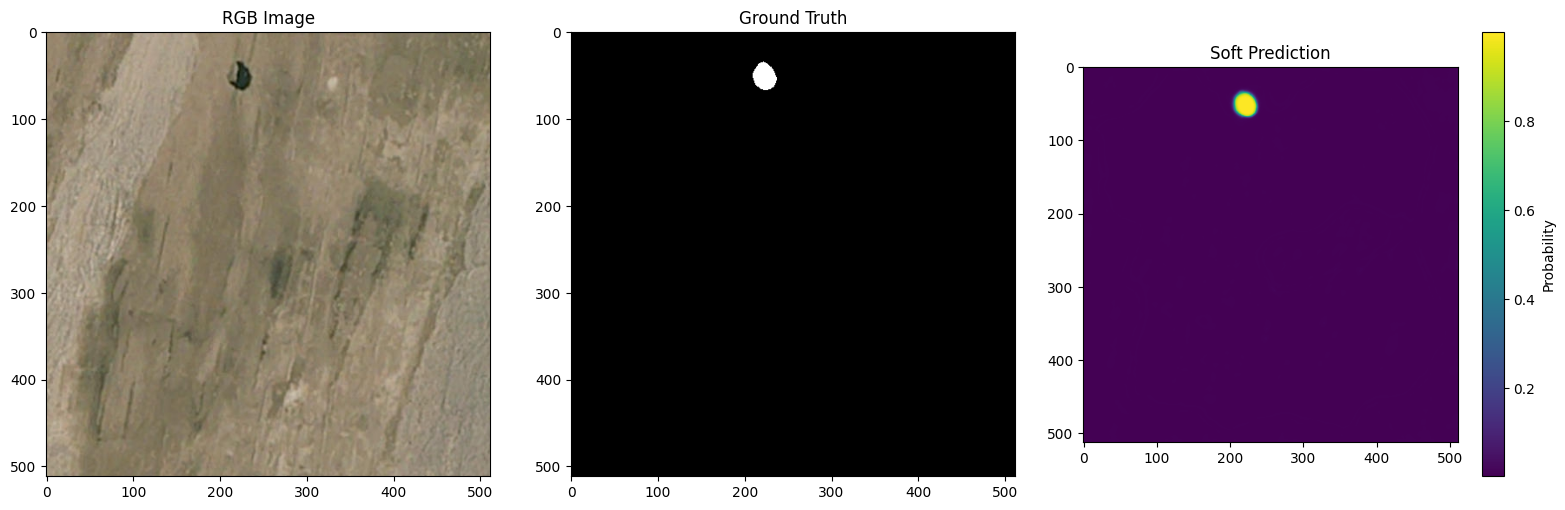

In [15]:
# === Visualize Sample Predictions with Soft Labels ===
for idx in range(10):
    plt.figure(figsize=(16, 5))

    # RGB Image
    plt.subplot(1, 3, 1)
    plt.imshow(X_test_rgb[idx])
    plt.title("RGB Image")

    # Ground Truth Mask
    plt.subplot(1, 3, 2)
    plt.imshow(y_test[idx].squeeze(), cmap="gray")
    plt.title("Ground Truth")

    # Soft Prediction (Probability Map)
    plt.subplot(1, 3, 3)
    plt.imshow(predictions[idx].squeeze(), cmap="viridis")  # or 'hot', 'plasma', etc.
    plt.colorbar(label="Probability")
    plt.title("Soft Prediction")

    plt.tight_layout()
    plt.show()


In [7]:
#model.save('D:/Osher/ISPRS_AUTOSINK1/new_models/training_with_100%_human_unet/')

INFO:tensorflow:Assets written to: D:/Osher/ISPRS_AUTOSINK1/new_models/training_with_100%_human_unet/assets


INFO:tensorflow:Assets written to: D:/Osher/ISPRS_AUTOSINK1/new_models/training_with_100%_human_unet/assets


In [ ]:
import tensorflow as tf

# Load the saved model
model_path = 'D:/Osher/ISPRS_AUTOSINK1/new_models/final_model_after_third_iteration_WDL0.07_0.5155/'
model_loaded = tf.keras.models.load_model(
    model_path,
    custom_objects={
        'weighted_dice_loss': weighted_dice_loss,
        'iou_metric': iou_metric,
        'bce_loss': bce_loss  # 🔥 add this line
    }
)
# === Compile the loaded model ===
model_loaded.compile(
    optimizer='adam',
    loss=weighted_dice_loss,
    metrics=[iou_metric]
)

# === Print model summary ===
model_loaded.summary()

In [ ]:
model_loaded = tf.keras.models.load_model(
    model_path,
    custom_objects={
        'weighted_dice_loss': weighted_dice_loss,
        'iou_metric': iou_metric,
        'bce_loss': bce_loss  # 🔥 add this line
    }
)

In [3]:
import segmentation_models as sm

Segmentation Models: using `keras` framework.


In [4]:
!pip install keras-unet-collection -q -U

In [61]:
# https://youtu.be/L5iV5BHkMzM
"""

Attention U-net:
https://arxiv.org/pdf/1804.03999.pdf

Recurrent residual Unet (R2U-Net) paper
https://arxiv.org/ftp/arxiv/papers/1802/1802.06955.pdf
(Check fig 4.)

Note: Batch normalization should be performed over channels after a convolution, 
In the following code axis is set to 3 as our inputs are of shape 
[None, height, width, channel]. Channel is axis=3.

Original code from below link but heavily modified.
https://github.com/MoleImg/Attention_UNet/blob/master/AttResUNet.py
"""

import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras import backend as K




##############################################################
'''
Useful blocks to build Unet

conv - BN - Activation - conv - BN - Activation - Dropout (if enabled)

'''


def conv_block(x, filter_size, size, dropout, batch_norm=False):
    
    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)
    
    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    return conv


def repeat_elem(tensor, rep):
    # lambda function to repeat Repeats the elements of a tensor along an axis
    #by a factor of rep.
    # If tensor has shape (None, 256,256,3), lambda will return a tensor of shape 
    #(None, 256,256,6), if specified axis=3 and rep=2.

     return layers.Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                          arguments={'repnum': rep})(tensor)


def res_conv_block(x, filter_size, size, dropout, batch_norm=False):
    '''
    Residual convolutional layer.
    Two variants....
    Either put activation function before the addition with shortcut
    or after the addition (which would be as proposed in the original resNet).
    
    1. conv - BN - Activation - conv - BN - Activation 
                                          - shortcut  - BN - shortcut+BN
                                          
    2. conv - BN - Activation - conv - BN   
                                     - shortcut  - BN - shortcut+BN - Activation                                     
    
    Check fig 4 in https://arxiv.org/ftp/arxiv/papers/1802/1802.06955.pdf
    '''

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation('relu')(conv)
    
    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    #conv = layers.Activation('relu')(conv)    #Activation before addition with shortcut
    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    shortcut = layers.Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm is True:
        shortcut = layers.BatchNormalization(axis=3)(shortcut)

    res_path = layers.add([shortcut, conv])
    res_path = layers.Activation('relu')(res_path)    #Activation after addition with shortcut (Original residual block)
    return res_path

def gating_signal(input, out_size, batch_norm=False):
    """
    resize the down layer feature map into the same dimension as the up layer feature map
    using 1x1 conv
    :return: the gating feature map with the same dimension of the up layer feature map
    """
    x = layers.Conv2D(out_size, (1, 1), padding='same')(input)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def attention_block(x, gating, inter_shape):
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

# Getting the x signal to the same shape as the gating signal
    theta_x = layers.Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same')(x)  # 16
    shape_theta_x = K.int_shape(theta_x)

# Getting the gating signal to the same number of filters as the inter_shape
    phi_g = layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)
    upsample_g = layers.Conv2DTranspose(inter_shape, (3, 3),
                                 strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),
                                 padding='same')(phi_g)  # 16

    concat_xg = layers.add([upsample_g, theta_x])
    act_xg = layers.Activation('relu')(concat_xg)
    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = layers.Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)
    upsample_psi = layers.UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)  # 32

    upsample_psi = repeat_elem(upsample_psi, shape_x[3])

    y = layers.multiply([upsample_psi, x])

    result = layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = layers.BatchNormalization()(result)
    return result_bn




def UNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    UNet, 
    
    '''
    # network structure
    FILTER_NUM = 16 # number of filters for the first layer
    FILTER_SIZE = 3 # size of the convolutional filter
    UP_SAMP_SIZE = 2 # size of upsampling filters
    

    inputs = layers.Input(input_shape, dtype=tf.float32)

    # Downsampling layers
    # DownRes 1, convolution + pooling
    conv_128 = conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
   
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, conv_16], axis=3)
    up_conv_16 = conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, conv_32], axis=3)
    up_conv_32 = conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, conv_64], axis=3)
    up_conv_64 = conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
   
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, conv_128], axis=3)
    up_conv_128 = conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers
   
    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=3)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model 
    model = models.Model(inputs, conv_final, name="UNet")
    print(model.summary())
    return model

def Attention_UNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    Attention UNet, 
    
    '''
    # network structure
    FILTER_NUM = 16 # number of basic filters for the first layer
    FILTER_SIZE = 3 # size of the convolutional filter
    UP_SAMP_SIZE = 2 # size of upsampling filters
    
    inputs = layers.Input(input_shape, dtype=tf.float32)

    # Downsampling layers
    # DownRes 1, convolution + pooling
    conv_128 = conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
    # UpRes 6, attention gated concatenation + upsampling + double residual convolution
    gating_16 = gating_signal(conv_8, 8*FILTER_NUM, batch_norm)
    att_16 = attention_block(conv_16, gating_16, 8*FILTER_NUM)
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, att_16], axis=3)
    up_conv_16 = conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    gating_32 = gating_signal(up_conv_16, 4*FILTER_NUM, batch_norm)
    att_32 = attention_block(conv_32, gating_32, 4*FILTER_NUM)
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, att_32], axis=3)
    up_conv_32 = conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    gating_64 = gating_signal(up_conv_32, 2*FILTER_NUM, batch_norm)
    att_64 = attention_block(conv_64, gating_64, 2*FILTER_NUM)
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, att_64], axis=3)
    up_conv_64 = conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
    gating_128 = gating_signal(up_conv_64, FILTER_NUM, batch_norm)
    att_128 = attention_block(conv_128, gating_128, FILTER_NUM)
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, att_128], axis=3)
    up_conv_128 = conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers
    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=3)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model integration
    model = models.Model(inputs, conv_final, name="Attention_UNet")
    return model

def Attention_ResUNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    Rsidual UNet, with attention 
    
    '''
    # network structure
    FILTER_NUM = 16 # number of basic filters for the first layer
    FILTER_SIZE = 3 # size of the convolutional filter
    UP_SAMP_SIZE = 2 # size of upsampling filters
    # input data
    # dimension of the image depth
    inputs = layers.Input(input_shape, dtype=tf.float32)
    axis = 3

    # Downsampling layers
    # DownRes 1, double residual convolution + pooling
    conv_128 = res_conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = res_conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = res_conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = res_conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = res_conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
    # UpRes 6, attention gated concatenation + upsampling + double residual convolution
    gating_16 = gating_signal(conv_8, 8*FILTER_NUM, batch_norm)
    att_16 = attention_block(conv_16, gating_16, 8*FILTER_NUM)
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, att_16], axis=axis)
    up_conv_16 = res_conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    gating_32 = gating_signal(up_conv_16, 4*FILTER_NUM, batch_norm)
    att_32 = attention_block(conv_32, gating_32, 4*FILTER_NUM)
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, att_32], axis=axis)
    up_conv_32 = res_conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    gating_64 = gating_signal(up_conv_32, 2*FILTER_NUM, batch_norm)
    att_64 = attention_block(conv_64, gating_64, 2*FILTER_NUM)
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, att_64], axis=axis)
    up_conv_64 = res_conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
    gating_128 = gating_signal(up_conv_64, FILTER_NUM, batch_norm)
    att_128 = attention_block(conv_128, gating_128, FILTER_NUM)
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, att_128], axis=axis)
    up_conv_128 = res_conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers
    
    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=axis)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model integration
    model = models.Model(inputs, conv_final, name="AttentionResUNet")
    return model

input_shape = (512,512,3)
model_RGB = Attention_UNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True)

In [62]:
# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_RGB.compile(optimizer=optimizer, loss=bce_loss, metrics=[iou_metric])

# Memory usage callback
class MemoryUsageCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        try:
            memory_info = tf.config.experimental.get_memory_info('GPU:0')
            mem_usage = memory_info['current'] / (1024**2)
            print(f"Epoch {epoch+1}: GPU Memory Usage = {mem_usage:.2f} MB")
        except:
            print(f"Epoch {epoch+1}: Unable to fetch memory info.")

# Train
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=False)
history = model_RGB.fit(
    X_train_rgb, y_train,
    batch_size=8,
    validation_data=(X_val_rgb, y_val),
    epochs=50,
    callbacks=[early_stopping, MemoryUsageCallback()]
)

Epoch 1/50
61/61 [==============================] - 18s 238ms/step - loss: 0.6871 - iou_metric: 0.0901 - val_loss: 10.4369 - val_iou_metric: 0.0323
Epoch 2/50
61/61 [==============================] - 14s 227ms/step - loss: 0.6338 - iou_metric: 0.1691 - val_loss: 0.8605 - val_iou_metric: 0.0537
Epoch 3/50
61/61 [==============================] - 14s 229ms/step - loss: 0.6041 - iou_metric: 0.1840 - val_loss: 1.0092 - val_iou_metric: 0.0487
Epoch 4/50
61/61 [==============================] - 14s 231ms/step - loss: 0.5754 - iou_metric: 0.2091 - val_loss: 0.5832 - val_iou_metric: 0.1471
Epoch 5/50
61/61 [==============================] - 14s 229ms/step - loss: 0.5513 - iou_metric: 0.2239 - val_loss: 0.5422 - val_iou_metric: 0.1727
Epoch 6/50
61/61 [==============================] - 14s 227ms/step - loss: 0.5228 - iou_metric: 0.2581 - val_loss: 0.5310 - val_iou_metric: 0.2115
Epoch 7/50
61/61 [==============================] - 14s 227ms/step - loss: 0.5015 - iou_metric: 0.2781 - val_loss: 0.

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50


# Memory usage callback
class MemoryUsageCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        try:
            memory_info = tf.config.experimental.get_memory_info('GPU:0')
            mem_usage = memory_info['current'] / (1024**2)
            print(f"Epoch {epoch+1}: GPU Memory Usage = {mem_usage:.2f} MB")
        except:
            print(f"Epoch {epoch+1}: Unable to fetch memory info.")

# ===============================
#       Model Architecture
# ===============================

def get_upsampling_block(inp, channels):
    return layers.Conv2DTranspose(channels, (2, 2), strides=(2, 2), padding='same')(inp)

def get_conv_block(inp, channels):
    x = layers.Conv2D(channels, (3, 3), padding='same', kernel_initializer='he_normal')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.Conv2D(channels, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    return x

def get_resnet50_unet(input_shape=(512, 512, 3), num_classes=1):
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)

    # Encoder skip connections
    inp = base_model.input
    s1 = base_model.get_layer('conv1_relu').output         # 256×256
    s2 = base_model.get_layer('conv2_block3_out').output   # 128×128
    s3 = base_model.get_layer('conv3_block4_out').output   # 64×64
    s4 = base_model.get_layer('conv4_block6_out').output   # 32×32
    d = base_model.get_layer('conv5_block3_out').output    # 16×16 (bottleneck)

    # Decoder
    d1 = get_upsampling_block(d, 512)
    d1 = layers.Concatenate()([d1, s4])
    d1 = get_conv_block(d1, 512)

    d2 = get_upsampling_block(d1, 256)
    d2 = layers.Concatenate()([d2, s3])
    d2 = get_conv_block(d2, 256)

    d3 = get_upsampling_block(d2, 128)
    d3 = layers.Concatenate()([d3, s2])
    d3 = get_conv_block(d3, 128)

    d4 = get_upsampling_block(d3, 64)
    d4 = layers.Concatenate()([d4, s1])
    d4 = get_conv_block(d4, 64)

    output = get_upsampling_block(d4, 32)
    output = get_conv_block(output, 32)

    output = layers.Conv2D(num_classes, 1, padding='same')(output)
    output = layers.Activation('sigmoid' if num_classes == 1 else 'softmax')(output)

    return models.Model(inp, output, name="ResNet50_UNet")


model = get_resnet50_unet(input_shape=(512, 512, 3), num_classes=1)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=dice_loss,
              metrics=[iou_metric])
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=False)

model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    batch_size=8,
    epochs=50,
    callbacks=[early_stopping, MemoryUsageCallback()],
    verbose=1
)


Epoch 1/50
61/61 [==============================] - 42s 485ms/step - loss: 0.8256 - iou_metric: 0.0972 - val_loss: 0.9484 - val_iou_metric: 0.0243
Epoch 2/50
61/61 [==============================] - 27s 450ms/step - loss: 0.6959 - iou_metric: 0.1826 - val_loss: 0.9484 - val_iou_metric: 0.0243
Epoch 3/50
61/61 [==============================] - 28s 455ms/step - loss: 0.5571 - iou_metric: 0.2888 - val_loss: 0.9484 - val_iou_metric: 0.0243
Epoch 4/50
61/61 [==============================] - 28s 458ms/step - loss: 0.4966 - iou_metric: 0.3422 - val_loss: 0.8250 - val_iou_metric: 0.0908
Epoch 5/50
61/61 [==============================] - 28s 460ms/step - loss: 0.4598 - iou_metric: 0.3783 - val_loss: 0.9050 - val_iou_metric: 0.0501
Epoch 6/50
61/61 [==============================] - 28s 462ms/step - loss: 0.4138 - iou_metric: 0.4239 - val_loss: 0.6464 - val_iou_metric: 0.2580
Epoch 7/50
61/61 [==============================] - 28s 464ms/step - loss: 0.4472 - iou_metric: 0.3896 - val_loss: 0.7

In [ ]:
'''
The U-Net architecture is adjusted to take RGB Depth input.
The conv_block and upsample_block functions remain the same, ensuring consistency in the architecture.
The input shape is defined for the RGB input.
The model is compiled and trained similarly to the two-head version.
An example prediction is generated and visualized for the first validation sample, showing the input RGB image, ground truth, and the predicted binary mask.

'''

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def conv_block(input_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.Conv2D(num_filters, kernel_size=(kernel_size, kernel_size), padding="same")(input_tensor)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    x = layers.Conv2D(num_filters, kernel_size=(kernel_size, kernel_size), padding="same")(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x

def upsample_block(input_tensor, skip_tensor, num_filters, kernel_size=3, batch_norm=True, dropout_rate=0.0):
    x = layers.UpSampling2D((2, 2))(input_tensor)
    x = layers.Concatenate()([x, skip_tensor])
    x = conv_block(x, num_filters, kernel_size, batch_norm, dropout_rate)
    return x

def UNetRGBD(input_shape, num_classes=1, dropout_rate=0.0, batch_norm=True):
    FILTER_NUM = 16  # Number of filters for the first layer
    FILTER_SIZE = 3  # Size of the convolutional filter

    input_layer = layers.Input(input_shape, dtype=tf.float32)

    # Encoder
    conv1 = conv_block(input_layer, FILTER_NUM, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = conv_block(pool1, FILTER_NUM * 2, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = conv_block(pool2, FILTER_NUM * 4, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = conv_block(pool3, FILTER_NUM * 8, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)
    center = conv_block(pool4, FILTER_NUM * 16, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)

    # Decoder
    up4 = upsample_block(center, conv4, FILTER_NUM * 8, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up3 = upsample_block(up4, conv3, FILTER_NUM * 4, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up2 = upsample_block(up3, conv2, FILTER_NUM * 2, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)
    up1 = upsample_block(up2, conv1, FILTER_NUM, kernel_size=FILTER_SIZE, batch_norm=batch_norm, dropout_rate=dropout_rate)

    # Final convolution
    output = layers.Conv2D(num_classes, kernel_size=(1, 1), activation='sigmoid')(up1)

    # Model
    model = models.Model(inputs=input_layer, outputs=output, name="UNetRGBD")
    model.summary()
    return model

# Define the input shape for the RGB-D input (4 channels)
input_shape = (512, 512, 4)

# Creating the model with one input shape
model = UNetRGBD(input_shape, num_classes=1)

if model is None:
    print("Model creation failed!")
else:
    print("Model created successfully!")

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[iou_metric])

    # Combine RGB and Depth images into a single input with 4 channels
    X_train_combined = np.concatenate([X_train_rgb, X_train_depth], axis=-1)
    X_val_combined = np.concatenate([X_val_rgb, X_val_depth], axis=-1)
    X_test_combined = np.concatenate([X_test_rgb, X_test_depth], axis=-1)

    # Train the model without data augmentation
    history = model.fit(
        X_train, y_train,
        batch_size=8,
        validation_data=(X_val, y_val),
        epochs=200
    )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate predictions for the entire test set
predictions = model.predict(X_test)

# Apply a threshold to the predictions
threshold = 0.5
predictions_binary = (predictions > threshold).astype(np.uint8)

# Function to calculate IoU
def calculate_iou(y_true, y_pred):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    intersection = np.sum(y_true_flat * y_pred_flat)
    union = np.sum(y_true_flat) + np.sum(y_pred_flat) - intersection
    iou_score = intersection / union if union != 0 else 0
    return iou_score

# Calculate IoU for each test sample and the mean IoU
ious = []
for i in range(len(X_test_rgb)):
    iou_score = calculate_iou(y_test[i], predictions_binary[i])
    ious.append(iou_score)

mean_iou = np.mean(ious)

# Print the mean IoU
print("Mean IoU for the test set: {:.2f}".format(mean_iou))

# Display two example predictions
for example_idx in [0, 1]:
    input_rgb = X_test[example_idx:example_idx+1]
    ground_truth = y_test[example_idx:example_idx+1]
    prediction_binary = predictions_binary[example_idx:example_idx+1]

    # Calculate IoU for the example
    iou_score = calculate_iou(ground_truth, prediction_binary)

    # Display the input images, ground truth, and prediction
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(input_rgb[0])
    plt.title('Input RGB Image')
    plt.subplot(1, 3, 2)
    plt.imshow(ground_truth[0].squeeze(), cmap='gray')
    plt.title('Ground Truth')
    plt.subplot(1, 3, 3)
    plt.imshow(prediction_binary[0].squeeze(), cmap='gray')
    plt.title('Prediction (IoU: {:.2f})'.format(iou_score))
    plt.show()
